In [1]:
# Installing and Importing Requirements

import copy
import time
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)


In [2]:
# Fixes Randomness in NumPy
SEED = 42 #Fixes randomness so results don't change everytime and result table is consistent
np.random.seed(SEED)

# Fixes Randomness in Pytorch
torch.manual_seed(SEED)

# using GPU if available or use CPU

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# Defining Path of the dataset 

HR_DATA_PATH = Path("stackoverflow_full.csv")  

Using device: cpu


In [3]:
# Dictionary of Hyperparameters to Experiment with

CONFIG = {
    # Federated Learning Settings
    "rounds":               10,#no of communication rounds, server client interaction happens 10 times
    "local_epochs":         3, #how much each client trains before sharing updates
    "num_clients":          5, #no of simulated clients
    
    # Model Settings
    "batch_size":           256, #How many samples per training step
    "lr_tabular":           1e-3, #How fast model updates weight 
    "hidden_dim":           128, #Size of hidden layer in neural network
    
    "fedprox_mu":           0.1, #Controls how much local models stay close to global model
    "fedproto_lambda":      0.5, #Controls importance of prototype loss
    "dp_noise_multiplier":  0.5, #Amount of noise added
    "dp_clip":              1.0, #Limits how big each client update can be, Prevents one client from dominating
    "tabular_client_alpha": 0.6, #Controls how data is split across clients
}

In [4]:
# Loading the HR Dataset

def load_hr_dataset(csv_path: Path):
    if not csv_path.exists():
        alt_path = Path("core") / csv_path
        csv_path = alt_path if alt_path.exists() else csv_path
    if not csv_path.exists():
        raise FileNotFoundError(
            f"HR dataset not found at {csv_path}. Check HR_DATA_PATH."
        )
        # Cleaning the columns 

    # reading csv into dataframe
    df = pd.read_csv(csv_path)

    # For every column name convert to string and remove spaces
    df.columns = [str(c).strip() for c in df.columns]

    #Remove unwanted column
    if "Unnamed: 0" in df.columns:
        df = df.drop(columns=["Unnamed: 0"])
    target_col = "Employed" #Define target column

    # Remove completely empty rows and completely empty columns
    df = df.dropna(axis=0, how="all").dropna(axis=1, how="all")

    # Clean text columns
    for col in df.select_dtypes(include="object").columns:
        df[col] = df[col].astype(str).str.strip()

    # X contains all the input colums except target col
    X = df.drop(columns=[target_col]).copy()
    
    # Y contains the target column
    y = df[target_col].copy()

    # Information Dictionary 
    class_counts = y.value_counts().to_dict() # counts how many samples in each class(employed, unemployed)
    # Metadata of the dataset
    return X, y, {
        "target_column":  target_col, #Stores the name of the target column
        "rows":           len(df), #Total number of rows in dataset
        "columns":        list(df.columns), #List of cols in dataset
        "class_counts":   class_counts, #Number of samples in each class
        "class_balance":  {k: round(v / len(y), 4) for k, v in class_counts.items()}, #Shows balance of classes (Balanced/Imbalanced dataset)
        "notes":          "Dropped Unnamed: 0 and used Employed as binary target. All strings stripped.", #Just a description of what cleaning was done
    }

In [5]:
#Feature Engineering - Turing raw columns into meaningful features
def engineer_hr_features(X: pd.DataFrame) -> pd.DataFrame:
    X = X.copy() #Creates a copy so you don’t modify the original data
    
    # Clean text columns (again)
    for col in X.select_dtypes(include="object").columns:
        X[col] = X[col].astype(str).str.strip()

    if "HaveWorkedWith" in X.columns:
        
        #Fill missing values with empty string
        hww = X["HaveWorkedWith"].fillna("")
        
        # Count number of technologies
        X["TechStackCount"] = hww.apply(lambda s: len([t for t in s.split(";") if t.strip()]))
        X["HasPython"]      = hww.str.contains("Python",     regex=False).astype(int)
        X["HasSQL"]         = hww.str.contains("SQL",        regex=False).astype(int)
        X["HasDocker"]      = hww.str.contains("Docker",     regex=False).astype(int)
        X["HasAWS"]         = hww.str.contains("AWS",        regex=False).astype(int)
        X["HasCloud"]       = hww.str.contains("AWS|Azure|Google Cloud", regex=True).astype(int)
        X["HasJS"]          = hww.str.contains("JavaScript", regex=False).astype(int)
        X["HasTypeScript"]  = hww.str.contains("TypeScript", regex=False).astype(int)
        X = X.drop(columns=["HaveWorkedWith"])

        #Handle experience columns
        
    # Check if both columns exist
    if {"YearsCode", "YearsCodePro"}.issubset(X.columns):
        X["YearsCode"]    = pd.to_numeric(X["YearsCode"],    errors="coerce")
        X["YearsCodePro"] = pd.to_numeric(X["YearsCodePro"], errors="coerce")
        
    #Create new feature ( how much of coding was non professional ) 
        X["YearsCodeGap"] = (X["YearsCode"] - X["YearsCodePro"]).clip(lower=0)
        
    # Create binary feature
    if "MainBranch" in X.columns:
        X["IsDeveloper"] = (X["MainBranch"].str.strip() == "Dev").astype(int)

    return X



In [6]:
# Preprocessing 

# Separate numeric and categorical columns
def build_preprocessor(X_train: pd.DataFrame):
    numeric_cols     = X_train.select_dtypes(include=[np.number, "bool"]).columns.tolist()
    categorical_cols = [c for c in X_train.columns if c not in numeric_cols]
    numeric_pipe = Pipeline([
        # Handle missing values by replacing with median and scale valye
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
    ])

    # Replace missing with most common value
    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot",  OneHotEncoder(handle_unknown="ignore")),
    ])
    preprocessor = ColumnTransformer([
        ("num", numeric_pipe,     numeric_cols),
        ("cat", categorical_pipe, categorical_cols),
    ])
    
    # return preprocessing pipeline with list of numeric and categorical cols
    return preprocessor, numeric_cols, categorical_cols

In [7]:
# defining a function that prepares my HR dataset using a country based split

def prepare_hr_dataset_country_shift(
    
    X: pd.DataFrame, y,
    domain_col="Country",
    num_ood_countries=3, #Number of countries to keep as OOD (unseen)
    min_country_samples=300 # Only consider countries with enough data
):
    # Creates a copy of your feature data
    df = X.copy()
    # Converts y into a pandas Series
    y_series = pd.Series(y).copy()
    # Converts text labels → numbers
    label_encoder = LabelEncoder()
    df["_target"] = label_encoder.fit_transform(y_series.astype(str))

    # Group data by country and compute how much data and 
    # how many classes each country has.
    country_stats = (
        df.groupby(domain_col)["_target"]
        .agg(n_samples="count", n_classes="nunique")
        .sort_values("n_samples", ascending=False)
    )

    # Keep only countries that have enough data AND at least 2 classes.
    eligible = country_stats[
        (country_stats["n_samples"] >= min_country_samples) &
        (country_stats["n_classes"] >= 2)
    ]

    # If possible, don’t choose United States of America as one of the OOD countries.
    preferred_drop = "United States of America"
    if preferred_drop in eligible.index and len(eligible) > num_ood_countries:
        eligible = eligible.drop(preferred_drop)

    if len(eligible) < num_ood_countries:
        eligible = country_stats[country_stats["n_samples"] >= min_country_samples]
        if preferred_drop in eligible.index and len(eligible) > num_ood_countries:
            eligible = eligible.drop(preferred_drop)

    ood_countries = eligible.index[:num_ood_countries].tolist()
    print(f"OOD countries selected: {ood_countries}")

    seen_df = df[~df[domain_col].isin(ood_countries)].copy()
    ood_df  = df[df[domain_col].isin(ood_countries)].copy()
    
    # Checks whether each row’s country is in the OOD list.
    stratify_seen = seen_df["_target"] if len(np.unique(seen_df["_target"])) > 1 else None

    # 70% train, 30% temp
    train_df, temp_df = train_test_split(
        seen_df,
        test_size=0.30,
        random_state=SEED,
        stratify=stratify_seen
    )

    # 15% val, 15% IND test
    stratify_temp = temp_df["_target"] if len(np.unique(temp_df["_target"])) > 1 else None
    val_df, ind_df = train_test_split(
        temp_df,
        test_size=0.50,
        random_state=SEED,
        stratify=stratify_temp
    )

    X_train_raw = train_df.drop(columns=["_target"])
    X_val_raw   = val_df.drop(columns=["_target"])
    X_ind_raw   = ind_df.drop(columns=["_target"])
    X_ood_raw   = ood_df.drop(columns=["_target"])

    y_train = train_df["_target"].to_numpy(dtype=np.int64)
    y_val   = val_df["_target"].to_numpy(dtype=np.int64)
    y_ind   = ind_df["_target"].to_numpy(dtype=np.int64)
    y_ood   = ood_df["_target"].to_numpy(dtype=np.int64)

    preprocessor, numeric_cols, categorical_cols = build_preprocessor(X_train_raw)
    
    # Fit on train, transform all splits
    X_train_proc = preprocessor.fit_transform(X_train_raw)
    X_val_proc   = preprocessor.transform(X_val_raw)
    X_ind_proc   = preprocessor.transform(X_ind_raw)
    X_ood_proc   = preprocessor.transform(X_ood_raw)

    # Convert sparse matrices to dense arrays if needed
    if hasattr(X_train_proc, "toarray"):
        X_train_proc = X_train_proc.toarray()
        X_val_proc   = X_val_proc.toarray()
        X_ind_proc   = X_ind_proc.toarray()
        X_ood_proc   = X_ood_proc.toarray()
        
    # Convert all processed data to float32
    X_train_proc = X_train_proc.astype(np.float32)
    X_val_proc   = X_val_proc.astype(np.float32)
    X_ind_proc   = X_ind_proc.astype(np.float32)
    X_ood_proc   = X_ood_proc.astype(np.float32)

    # Keep track of sensitive columns
    sensitive_cols = [
        c for c in ["Gender", "Age", "MentalHealth", "Accessibility"]
        if c in X_train_raw.columns
    ]
    
    #Here is all the data + metadata needed for training, evaluation, and analysis
    return {
        "X_train":      X_train_proc,
        "X_val":        X_val_proc,
        "X_test":       X_ind_proc,
        "X_ind_test":   X_ind_proc,
        "X_ood_test":   X_ood_proc,
        "y_train":      y_train,
        "y_val":        y_val,
        "y_test":       y_ind,
        "y_ind_test":   y_ind,
        "y_ood_test":   y_ood,
        "input_dim":    X_train_proc.shape[1],
        "model_type":   "tabular",
        "num_classes":  int(len(np.unique(y_train))),
        "label_encoder": label_encoder,
        "preprocessor": preprocessor,
        "numeric_cols": numeric_cols,
        "categorical_cols": categorical_cols,
        "ood_countries": ood_countries,
        "X_train_raw":  X_train_raw,
        "X_val_raw":    X_val_raw,
        "X_ind_raw":    X_ind_raw,
        "X_ood_raw":    X_ood_raw,
        "sensitive_cols": sensitive_cols,
    }

In [8]:
X, y, hr_info = load_hr_dataset(HR_DATA_PATH)

print(f"Rows: {hr_info['rows']}")
print(f"Target: {hr_info['target_column']}")
print(f"Class balance: {hr_info['class_balance']}")

X = engineer_hr_features(X)
hr_data = prepare_hr_dataset_country_shift(X, y)

print(f"Train size: {len(hr_data['X_train'])}")
print(f"Val size: {len(hr_data['X_val'])}")
print(f"Test size: {len(hr_data['X_test'])}")
print(f"OOD test size: {len(hr_data['X_ood_test'])}")
print(f"OOD countries: {hr_data['ood_countries']}")

Rows: 73462
Target: Employed
Class balance: {1: 0.5362, 0: 0.4638}
OOD countries selected: ['Germany', 'India', 'United Kingdom of Great Britain and Northern Ireland']
Train size: 40613
Val size: 8703
Test size: 8703
OOD test size: 15443
OOD countries: ['Germany', 'India', 'United Kingdom of Great Britain and Northern Ireland']


In [9]:
import copy
import time
import pickle
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

In [10]:
def dirichlet_client_split(y, num_clients=5, alpha=0.6, min_size=32):
    y = np.asarray(y)
    classes = np.unique(y)

    while True:
        client_indices = [[] for _ in range(num_clients)]

        for cls in classes:
            cls_idx = np.where(y == cls)[0]
            np.random.shuffle(cls_idx)

            proportions = np.random.dirichlet(alpha=np.repeat(alpha, num_clients))
            cut_points = (np.cumsum(proportions)[:-1] * len(cls_idx)).astype(int)
            splits = np.split(cls_idx, cut_points)

            for client_id, split in enumerate(splits):
                client_indices[client_id].extend(split.tolist())

        sizes = [len(idx) for idx in client_indices]
        if min(sizes) >= min_size:
            return [np.array(sorted(idx)) for idx in client_indices]



In [11]:
def build_client_datasets(hr_data, num_clients=5, alpha=0.6, min_size=32):
    client_indices = dirichlet_client_split(
        hr_data["y_train"],
        num_clients=num_clients,
        alpha=alpha,
        min_size=min_size
    )

    client_sets = []
    client_sizes = []

    for idx in client_indices:
        Xc = hr_data["X_train"][idx]
        yc = hr_data["y_train"][idx]
        client_sets.append((Xc, yc))
        client_sizes.append(len(idx))

    return client_sets, client_sizes



In [12]:
# ============================================
# RANDOM FOREST BUILDER
# ============================================
def build_rf_model(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    random_state=42,
):
    return RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=random_state,
        n_jobs=-1,
    )



In [13]:
# MODEL SIZE / COMMUNICATION
# ============================================
def model_num_bytes_sklearn(model):
    try:
        return len(pickle.dumps(model, protocol=pickle.HIGHEST_PROTOCOL))
    except Exception:
        return 0


In [14]:
# ============================================
# EVALUATION
# ============================================
def evaluate_sklearn_model(model, X, y):
    preds = model.predict(X)

    if hasattr(model, "predict_proba"):
        probs_arr = model.predict_proba(X)
        num_classes = probs_arr.shape[1]
    else:
        probs_arr = None
        num_classes = len(np.unique(y))

    unique_labels = np.unique(y)

    if probs_arr is not None and len(unique_labels) > 1:
        roc = roc_auc_score(
            y,
            probs_arr if num_classes > 2 else probs_arr[:, 1],
            multi_class="ovr",
            average="macro"
        )
    else:
        roc = float("nan")

    return {
        "accuracy": accuracy_score(y, preds),
        "balanced_accuracy": balanced_accuracy_score(y, preds),
        "f1_macro": f1_score(y, preds, average="macro"),
        "precision_macro": precision_score(y, preds, average="macro", zero_division=0),
        "recall_macro": recall_score(y, preds, average="macro", zero_division=0),
        "roc_auc": float(roc),
    }


In [15]:
# ============================================
# RF ENSEMBLE
# ============================================
class FederatedRFEnsemble:
    def __init__(self, models, weights=None, classes_=None, noise_std=0.0):
        self.models = models
        self.weights = weights if weights is not None else [1.0 / len(models)] * len(models)
        self.classes_ = classes_
        self.noise_std = noise_std

    def predict_proba(self, X):
        prob_list = [model.predict_proba(X) for model in self.models]

        probs = np.zeros_like(prob_list[0], dtype=np.float64)
        for w, p in zip(self.weights, prob_list):
            probs += w * p

        if self.noise_std > 0:
            noise = np.random.normal(0.0, self.noise_std, size=probs.shape)
            probs = probs + noise
            probs = np.clip(probs, 1e-9, None)
            probs = probs / probs.sum(axis=1, keepdims=True)

        return probs

    def predict(self, X):
        probs = self.predict_proba(X)
        idx = np.argmax(probs, axis=1)
        return self.classes_[idx]


def client_weights_from_sizes(sizes):
    total = sum(sizes)
    return [s / total for s in sizes]


def sample_global_anchor_data(hr_data, ratio=0.1, random_state=42):
    X_train = hr_data["X_train"]
    y_train = hr_data["y_train"]

    rng = np.random.default_rng(random_state)
    n = len(X_train)
    k = max(1, int(n * ratio))
    idx = rng.choice(n, size=k, replace=False)

    return X_train[idx], y_train[idx]


def build_class_prototype_bank(hr_data, max_per_class=50, random_state=42):
    X_train = hr_data["X_train"]
    y_train = hr_data["y_train"]

    rng = np.random.default_rng(random_state)
    classes = np.unique(y_train)

    X_proto_list = []
    y_proto_list = []

    for cls in classes:
        cls_idx = np.where(y_train == cls)[0]
        take = min(len(cls_idx), max_per_class)
        chosen = rng.choice(cls_idx, size=take, replace=False)
        X_proto_list.append(X_train[chosen])
        y_proto_list.append(y_train[chosen])

    X_proto = np.vstack(X_proto_list)
    y_proto = np.concatenate(y_proto_list)
    return X_proto, y_proto



In [16]:
def centralized_random_forest(hr_data):
    X_train = hr_data["X_train"]
    y_train = hr_data["y_train"]

    X_val = hr_data["X_val"]
    y_val = hr_data["y_val"]

    X_test = hr_data["X_test"]
    y_test = hr_data["y_test"]

    X_ood_test = hr_data["X_ood_test"]
    y_ood_test = hr_data["y_ood_test"]

    candidate_grid = [
        {"n_estimators": 100, "max_depth": 10},
        {"n_estimators": 200, "max_depth": 15},
        {"n_estimators": 300, "max_depth": None},
    ]

    best_model = None
    best_params = None
    best_val_acc = -1.0

    start = time.time()

    for params in candidate_grid:
        model = build_rf_model(
            n_estimators=params["n_estimators"],
            max_depth=params["max_depth"],
            random_state=SEED
        )
        model.fit(X_train, y_train)

        val_metrics = evaluate_sklearn_model(model, X_val, y_val)
        if val_metrics["accuracy"] > best_val_acc:
            best_val_acc = val_metrics["accuracy"]
            best_model = model
            best_params = params

    runtime = time.time() - start

    val_metrics   = evaluate_sklearn_model(best_model, X_val, y_val)
    test_metrics  = evaluate_sklearn_model(best_model, X_test, y_test)
    ood_metrics   = evaluate_sklearn_model(best_model, X_ood_test, y_ood_test)
    train_metrics = evaluate_sklearn_model(best_model, X_train, y_train)

    return {
        "method": "Centralized-RF",
        "model": best_model,
        "best_params": best_params,
        "val_metrics": val_metrics,
        "metrics": ood_metrics,
        "ind_metrics": test_metrics,
        "ood_metrics": ood_metrics,
        "runtime_s": runtime,
        "communication_mb": 0.0,
        "rounds": 0,
        "train_ood_gap": train_metrics["accuracy"] - ood_metrics["accuracy"],
    }


In [17]:
# ============================================
# FEDAVG (RF analogue)
# ============================================
def run_fedavg(hr_data, cfg, dp_noise_multiplier=0.0, dp_clip=None, record_history=False):
    client_sets, client_sizes = build_client_datasets(
        hr_data,
        num_clients=cfg["num_clients"],
        alpha=cfg.get("tabular_client_alpha", 0.6),
        min_size=32
    )

    X_train = hr_data["X_train"]
    y_train = hr_data["y_train"]
    X_val = hr_data["X_val"]
    y_val = hr_data["y_val"]
    X_test = hr_data["X_test"]
    y_test = hr_data["y_test"]
    X_ood_test = hr_data["X_ood_test"]
    y_ood_test = hr_data["y_ood_test"]

    weights = client_weights_from_sizes(client_sizes)

    best_val_acc = -1.0
    best_ensemble = None
    communication_bytes = 0
    history = []

    start = time.time()

    for rnd in range(cfg["rounds"]):
        client_models = []

        for i, (Xc, yc) in enumerate(client_sets):
            model = build_rf_model(
                n_estimators=cfg.get("rf_trees_per_client", 100),
                max_depth=cfg.get("rf_max_depth", None),
                random_state=SEED + rnd * 100 + i
            )
            model.fit(Xc, yc)
            client_models.append(model)

        communication_bytes += sum(model_num_bytes_sklearn(m) for m in client_models)

        ensemble = FederatedRFEnsemble(
            models=client_models,
            weights=weights,
            classes_=client_models[0].classes_,
            noise_std=dp_noise_multiplier if dp_noise_multiplier > 0 else 0.0
        )

        val_metrics = evaluate_sklearn_model(ensemble, X_val, y_val)

        if val_metrics["accuracy"] > best_val_acc:
            best_val_acc = val_metrics["accuracy"]
            best_ensemble = copy.deepcopy(ensemble)

        if record_history:
            history.append({
                "round": rnd + 1,
                "val_accuracy": val_metrics["accuracy"]
            })

    runtime = time.time() - start

    val_metrics   = evaluate_sklearn_model(best_ensemble, X_val, y_val)
    test_metrics  = evaluate_sklearn_model(best_ensemble, X_test, y_test)
    ood_metrics   = evaluate_sklearn_model(best_ensemble, X_ood_test, y_ood_test)
    train_metrics = evaluate_sklearn_model(best_ensemble, X_train, y_train)

    return {
        "method": "DP-FedAvg" if dp_noise_multiplier > 0 else "FedAvg",
        "model": best_ensemble,
        "val_metrics": val_metrics,
        "metrics": ood_metrics,
        "ind_metrics": test_metrics,
        "ood_metrics": ood_metrics,
        "runtime_s": runtime,
        "communication_mb": communication_bytes / (1024 ** 2),
        "rounds": cfg["rounds"],
        "train_ood_gap": train_metrics["accuracy"] - ood_metrics["accuracy"],
        "history": history,
    }



In [18]:

# ============================================
# FEDPROX (RF analogue)
# ============================================
def run_fedprox(hr_data, cfg):
    client_sets, client_sizes = build_client_datasets(
        hr_data,
        num_clients=cfg["num_clients"],
        alpha=cfg.get("tabular_client_alpha", 0.6),
        min_size=32
    )

    X_anchor, y_anchor = sample_global_anchor_data(
        hr_data,
        ratio=cfg.get("fedprox_anchor_ratio", 0.1),
        random_state=SEED
    )

    X_train = hr_data["X_train"]
    y_train = hr_data["y_train"]
    X_val = hr_data["X_val"]
    y_val = hr_data["y_val"]
    X_test = hr_data["X_test"]
    y_test = hr_data["y_test"]
    X_ood_test = hr_data["X_ood_test"]
    y_ood_test = hr_data["y_ood_test"]

    weights = client_weights_from_sizes(client_sizes)

    best_val_acc = -1.0
    best_ensemble = None
    communication_bytes = 0

    start = time.time()

    for rnd in range(cfg["rounds"]):
        client_models = []

        for i, (Xc, yc) in enumerate(client_sets):
            X_mix = np.vstack([Xc, X_anchor])
            y_mix = np.concatenate([yc, y_anchor])

            model = build_rf_model(
                n_estimators=cfg.get("rf_trees_per_client", 100),
                max_depth=cfg.get("rf_max_depth", None),
                random_state=SEED + rnd * 100 + i
            )
            model.fit(X_mix, y_mix)
            client_models.append(model)

        communication_bytes += sum(model_num_bytes_sklearn(m) for m in client_models)

        ensemble = FederatedRFEnsemble(
            models=client_models,
            weights=weights,
            classes_=client_models[0].classes_,
            noise_std=0.0
        )

        val_metrics = evaluate_sklearn_model(ensemble, X_val, y_val)

        if val_metrics["accuracy"] > best_val_acc:
            best_val_acc = val_metrics["accuracy"]
            best_ensemble = copy.deepcopy(ensemble)

    runtime = time.time() - start

    val_metrics   = evaluate_sklearn_model(best_ensemble, X_val, y_val)
    test_metrics  = evaluate_sklearn_model(best_ensemble, X_test, y_test)
    ood_metrics   = evaluate_sklearn_model(best_ensemble, X_ood_test, y_ood_test)
    train_metrics = evaluate_sklearn_model(best_ensemble, X_train, y_train)

    return {
        "method": "FedProx",
        "model": best_ensemble,
        "val_metrics": val_metrics,
        "metrics": ood_metrics,
        "ind_metrics": test_metrics,
        "ood_metrics": ood_metrics,
        "runtime_s": runtime,
        "communication_mb": communication_bytes / (1024 ** 2),
        "rounds": cfg["rounds"],
        "train_ood_gap": train_metrics["accuracy"] - ood_metrics["accuracy"],
    }



In [19]:
# ============================================
# FEDPROTO (RF analogue)
# ============================================
def run_fedproto(hr_data, cfg):
    client_sets, client_sizes = build_client_datasets(
        hr_data,
        num_clients=cfg["num_clients"],
        alpha=cfg.get("tabular_client_alpha", 0.6),
        min_size=32
    )

    X_proto, y_proto = build_class_prototype_bank(
        hr_data,
        max_per_class=cfg.get("fedproto_max_per_class", 50),
        random_state=SEED
    )

    X_train = hr_data["X_train"]
    y_train = hr_data["y_train"]
    X_val = hr_data["X_val"]
    y_val = hr_data["y_val"]
    X_test = hr_data["X_test"]
    y_test = hr_data["y_test"]
    X_ood_test = hr_data["X_ood_test"]
    y_ood_test = hr_data["y_ood_test"]

    weights = client_weights_from_sizes(client_sizes)

    best_val_acc = -1.0
    best_ensemble = None
    communication_bytes = 0

    start = time.time()

    for rnd in range(cfg["rounds"]):
        client_models = []

        for i, (Xc, yc) in enumerate(client_sets):
            X_mix = np.vstack([Xc, X_proto])
            y_mix = np.concatenate([yc, y_proto])

            model = build_rf_model(
                n_estimators=cfg.get("rf_trees_per_client", 100),
                max_depth=cfg.get("rf_max_depth", None),
                random_state=SEED + rnd * 100 + i
            )
            model.fit(X_mix, y_mix)
            client_models.append(model)

        communication_bytes += sum(model_num_bytes_sklearn(m) for m in client_models)

        ensemble = FederatedRFEnsemble(
            models=client_models,
            weights=weights,
            classes_=client_models[0].classes_,
            noise_std=0.0
        )

        val_metrics = evaluate_sklearn_model(ensemble, X_val, y_val)

        if val_metrics["accuracy"] > best_val_acc:
            best_val_acc = val_metrics["accuracy"]
            best_ensemble = copy.deepcopy(ensemble)

    runtime = time.time() - start

    val_metrics   = evaluate_sklearn_model(best_ensemble, X_val, y_val)
    test_metrics  = evaluate_sklearn_model(best_ensemble, X_test, y_test)
    ood_metrics   = evaluate_sklearn_model(best_ensemble, X_ood_test, y_ood_test)
    train_metrics = evaluate_sklearn_model(best_ensemble, X_train, y_train)

    return {
        "method": "FedProto",
        "model": best_ensemble,
        "val_metrics": val_metrics,
        "metrics": ood_metrics,
        "ind_metrics": test_metrics,
        "ood_metrics": ood_metrics,
        "runtime_s": runtime,
        "communication_mb": communication_bytes / (1024 ** 2),
        "rounds": cfg["rounds"],
        "train_ood_gap": train_metrics["accuracy"] - ood_metrics["accuracy"],
    }



In [20]:
# ============================================
# RUN ALL MODELS
# ============================================
RF_CONFIG = copy.deepcopy(CONFIG)
RF_CONFIG.update({
    "rf_trees_per_client": 100,
    "rf_max_depth": None,
    "fedprox_anchor_ratio": 0.10,
    "fedproto_max_per_class": 50,
})

print("\n--- Centralized Random Forest ---")
centralized = centralized_random_forest(hr_data)

print("\n--- FedAvg ---")
fedavg = run_fedavg(hr_data, RF_CONFIG, record_history=True)

print("\n--- FedProx ---")
fedprox = run_fedprox(hr_data, RF_CONFIG)

print("\n--- FedProto ---")
fedproto = run_fedproto(hr_data, RF_CONFIG)

print("\n--- DP-FedAvg ---")
dpfedavg = run_fedavg(
    hr_data,
    RF_CONFIG,
    dp_noise_multiplier=0.01,
    record_history=False
)

experiment_store = {
    "Centralized-RF": centralized,
    "FedAvg": fedavg,
    "FedProx": fedprox,
    "FedProto": fedproto,
    "DP-FedAvg": dpfedavg,
}

all_results = []
for result in [centralized, fedavg, fedprox, fedproto, dpfedavg]:
    all_results.append({
        "method":            result["method"],
        "val_acc":           result["val_metrics"]["accuracy"],
        "accuracy":          result["metrics"]["accuracy"],
        "ood_acc":           result["ood_metrics"]["accuracy"],
        "ind_acc":           result["ind_metrics"]["accuracy"],
        "balanced_accuracy": result["metrics"].get("balanced_accuracy", float("nan")),
        "roc_auc":           result["metrics"].get("roc_auc", float("nan")),
        "f1_macro":          result["metrics"]["f1_macro"],
        "precision_macro":   result["metrics"]["precision_macro"],
        "recall_macro":      result["metrics"]["recall_macro"],
        "runtime_s":         result["runtime_s"],
        "communication_mb":  result["communication_mb"],
        "rounds":            result["rounds"],
        "train_ood_gap":     result["train_ood_gap"],
    })

results_df = pd.DataFrame(all_results).sort_values("accuracy", ascending=False)

display(results_df.style.format({
    "val_acc": "{:.4f}",
    "accuracy": "{:.4f}",
    "ood_acc": "{:.4f}",
    "ind_acc": "{:.4f}",
    "balanced_accuracy": "{:.4f}",
    "roc_auc": "{:.4f}",
    "f1_macro": "{:.4f}",
    "precision_macro": "{:.4f}",
    "recall_macro": "{:.4f}",
    "runtime_s": "{:.2f}",
    "communication_mb": "{:.4f}",
    "train_ood_gap": "{:.4f}",
}))


--- Centralized Random Forest ---

--- FedAvg ---

--- FedProx ---

--- FedProto ---

--- DP-FedAvg ---


,method,val_acc,accuracy,ood_acc,ind_acc,balanced_accuracy,roc_auc,f1_macro,precision_macro,recall_macro,runtime_s,communication_mb,rounds,train_ood_gap
1,FedAvg,0.8198,0.8241,0.8241,0.8241,0.8236,0.9092,0.8238,0.8241,0.8236,45.81,1252.8007,10,0.0594
3,FedProto,0.8189,0.8236,0.8236,0.8219,0.8228,0.9095,0.8231,0.8239,0.8228,50.10,1227.5728,10,0.0560
4,DP-FedAvg,0.8179,0.8230,0.8230,0.8247,0.8221,0.9083,0.8225,0.8234,0.8221,49.46,1185.7899,10,0.1075
0,Centralized-RF,0.8188,0.8191,0.8191,0.8206,0.8183,0.9080,0.8186,0.8194,0.8183,17.57,0.0000,0,0.0384
2,FedProx,0.8132,0.8173,0.8173,0.8151,0.8147,0.9079,0.8153,0.8239,0.8147,62.08,1547.2907,10,0.0515


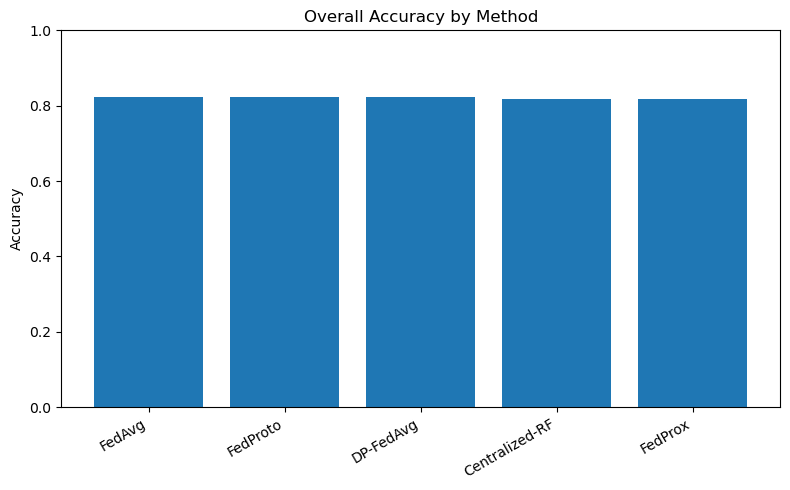

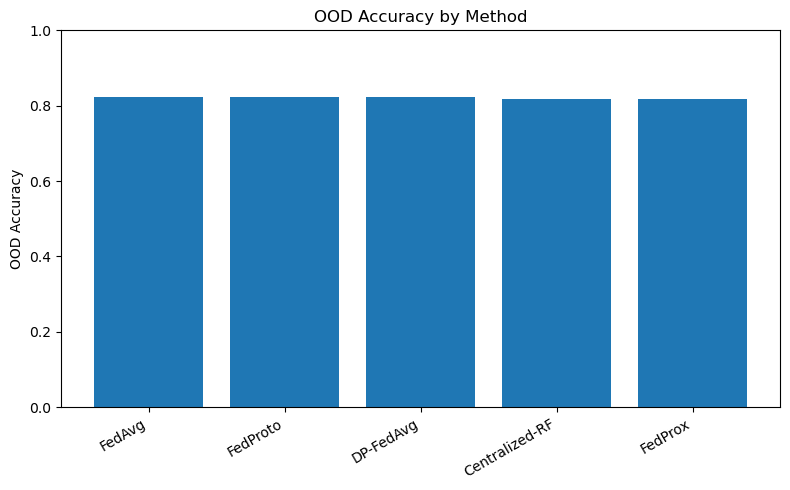

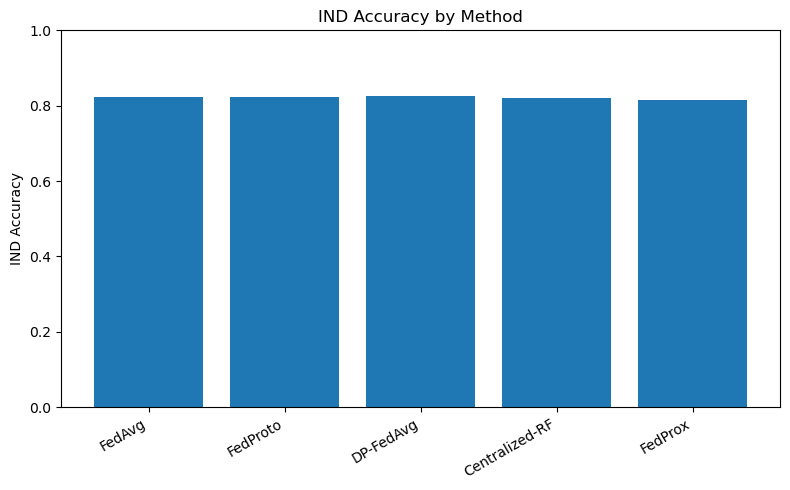

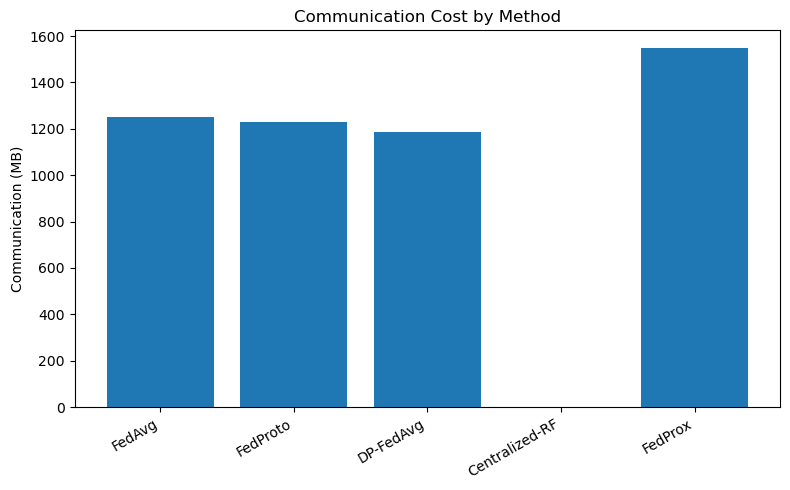

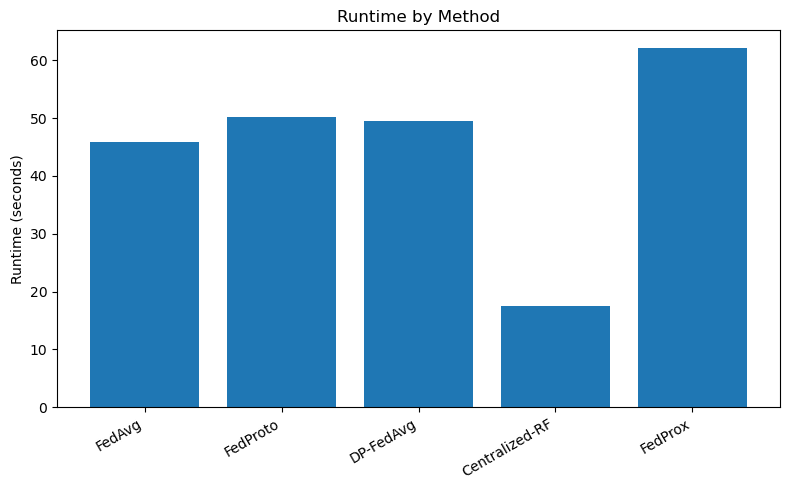

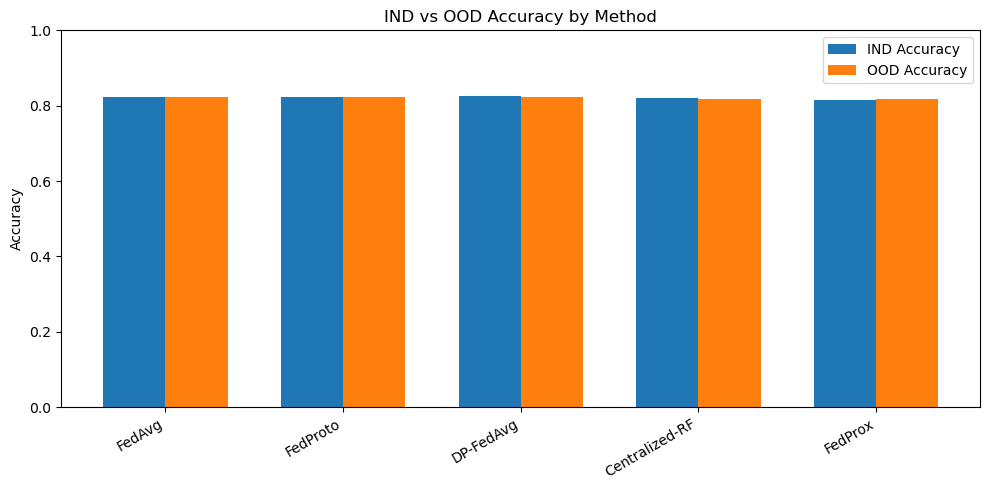

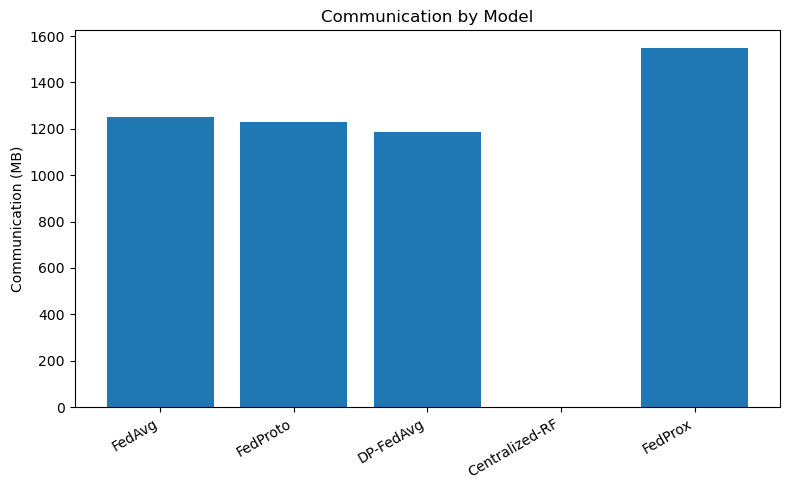

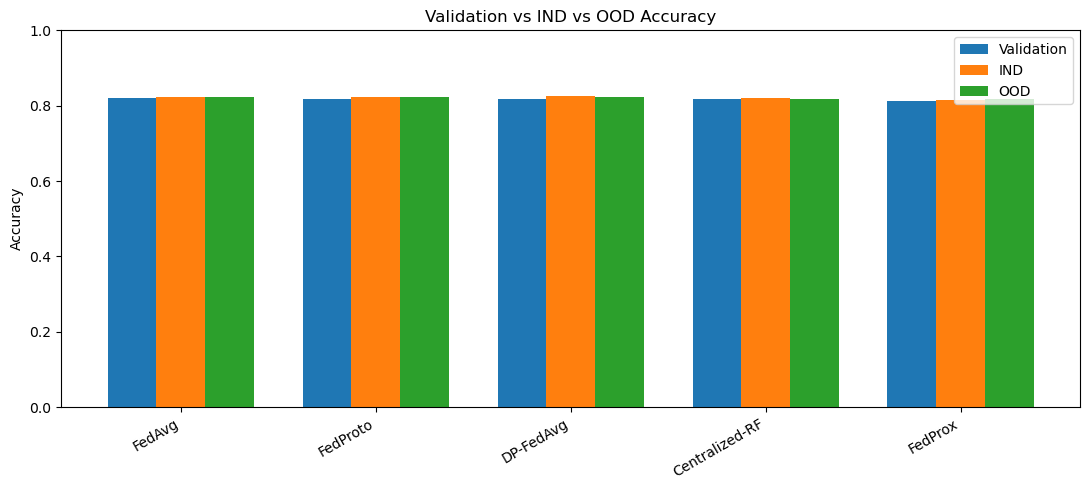

In [22]:
# ============================================
# VISUALIZATION
# ============================================
import matplotlib.pyplot as plt
import numpy as np

plot_df = results_df.copy()

# ----------------------------
# 1. Overall Accuracy
# ----------------------------
plt.figure(figsize=(8, 5))
plt.bar(plot_df["method"], plot_df["accuracy"])
plt.title("Overall Accuracy by Method")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# ----------------------------
# 2. OOD Accuracy
# ----------------------------
plt.figure(figsize=(8, 5))
plt.bar(plot_df["method"], plot_df["ood_acc"])
plt.title("OOD Accuracy by Method")
plt.ylabel("OOD Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# ----------------------------
# 3. IND Accuracy
# ----------------------------
plt.figure(figsize=(8, 5))
plt.bar(plot_df["method"], plot_df["ind_acc"])
plt.title("IND Accuracy by Method")
plt.ylabel("IND Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# ----------------------------
# 4. Communication Cost
# ----------------------------
plt.figure(figsize=(8, 5))
plt.bar(plot_df["method"], plot_df["communication_mb"])
plt.title("Communication Cost by Method")
plt.ylabel("Communication (MB)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# ----------------------------
# 5. Runtime
# ----------------------------
plt.figure(figsize=(8, 5))
plt.bar(plot_df["method"], plot_df["runtime_s"])
plt.title("Runtime by Method")
plt.ylabel("Runtime (seconds)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# ----------------------------
# 6. IND vs OOD Accuracy
# ----------------------------
x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, plot_df["ind_acc"], width, label="IND Accuracy")
plt.bar(x + width/2, plot_df["ood_acc"], width, label="OOD Accuracy")
plt.xticks(x, plot_df["method"], rotation=30, ha="right")
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("IND vs OOD Accuracy by Method")
plt.legend()
plt.tight_layout()
plt.show()

# ----------------------------
# 7. Communication by Model
# ----------------------------
plt.figure(figsize=(8, 5))
plt.bar(plot_df["method"], plot_df["communication_mb"])
plt.title("Communication by Model")
plt.ylabel("Communication (MB)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# ----------------------------
# 10. Validation vs IND vs OOD
# ----------------------------
x = np.arange(len(plot_df))
width = 0.25

plt.figure(figsize=(11, 5))
plt.bar(x - width, plot_df["val_acc"], width, label="Validation")
plt.bar(x,         plot_df["ind_acc"], width, label="IND")
plt.bar(x + width, plot_df["ood_acc"], width, label="OOD")

plt.xticks(x, plot_df["method"], rotation=30, ha="right")
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Validation vs IND vs OOD Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

Using device: cpu
Loading HR dataset...
Dataset info: 73462 rows | Target: Employed
Class balance: {1: 0.5362, 0: 0.4638}
OOD countries selected: ['Germany', 'India', 'United Kingdom of Great Britain and Northern Ireland']

Input dim: 196 | Classes: 2
Train size: 40613
Val size: 8703
IND test size: 8703
OOD test size: 15443
Sensitive columns: ['Gender', 'Age', 'MentalHealth', 'Accessibility']

--- Centralized Training ---

--- FedAvg ---

--- FedProx ---

--- FedProto ---

--- DP-FedAvg ---


,method,val_acc,accuracy,ood_acc,ind_acc,balanced_accuracy,roc_auc,f1_macro,precision_macro,recall_macro,runtime_s,communication_mb,rounds,train_ood_gap
1,FedAvg,0.8230,0.8290,0.8290,0.8250,0.8285,0.9141,0.8287,0.8290,0.8285,52.00,12.9646,10,0.0078
0,Centralized,0.8255,0.8287,0.8287,0.8284,0.8286,0.9142,0.8285,0.8284,0.8286,55.41,0.0000,0,0.0140
3,FedProto,0.8000,0.8090,0.8090,0.8051,0.8096,0.9106,0.8070,0.8202,0.8096,69.14,0.0488,10,0.0006
2,FedProx,0.7242,0.7350,0.7350,0.7243,0.7265,0.9021,0.7140,0.8046,0.7265,53.68,12.9646,10,-0.0066
4,DP-FedAvg,0.5402,0.5163,0.5163,0.5407,0.4992,0.4720,0.3413,0.3880,0.4992,49.44,12.9646,10,0.0234


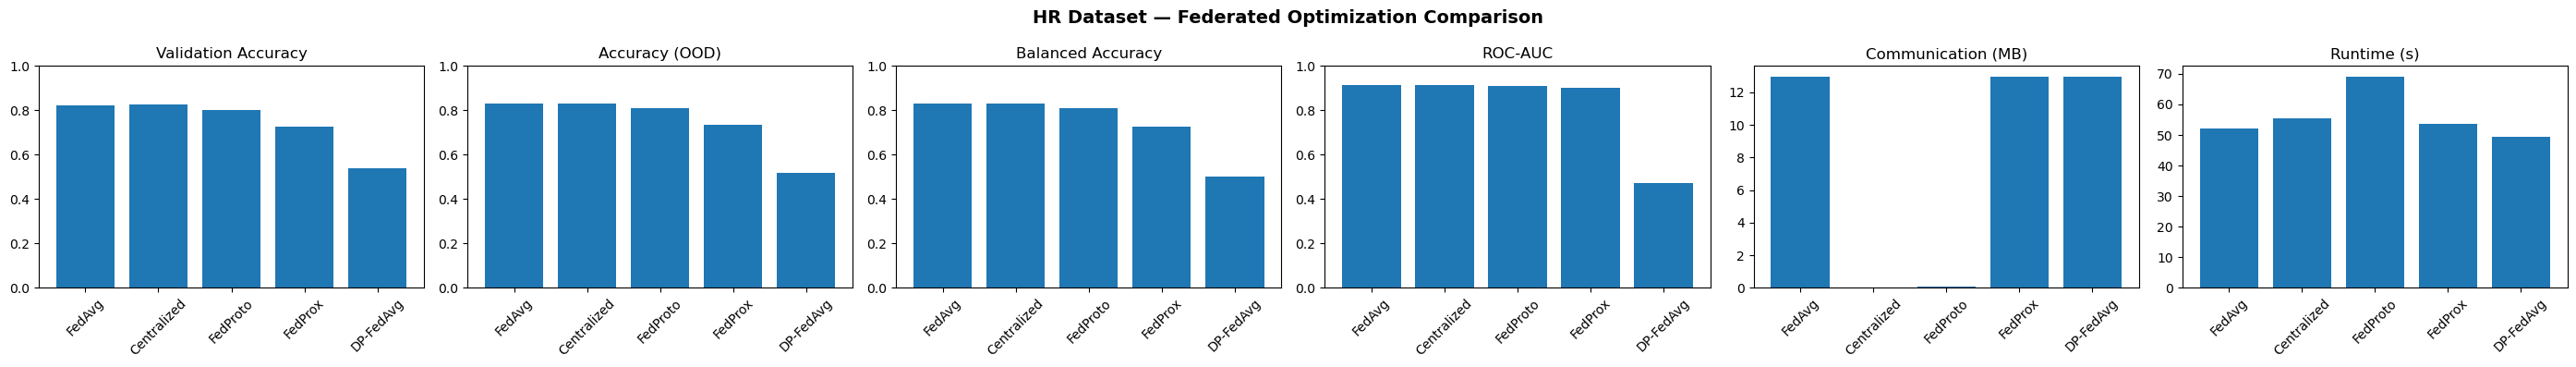

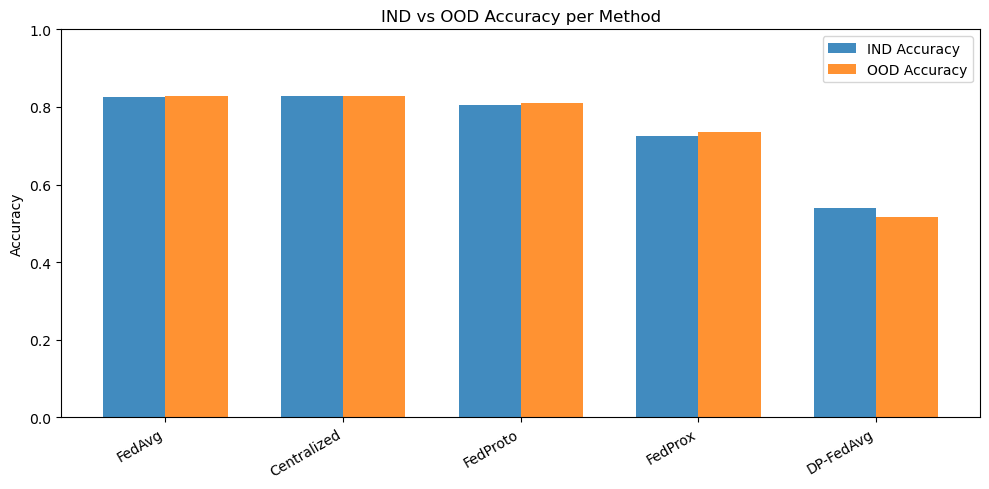

,val_acc,ood_acc,ind_acc,balanced_accuracy,roc_auc,f1_macro,train_ood_gap,communication_mb,runtime_s,rounds
method,,,,,,,,,,
Centralized,0.8255,0.8287,0.8284,0.8286,0.9142,0.8285,0.0140,0.0000,55.4136,0.0000
FedAvg,0.8230,0.8290,0.8250,0.8285,0.9141,0.8287,0.0078,12.9646,52.0024,10.0000
FedProx,0.7242,0.7350,0.7243,0.7265,0.9021,0.7140,-0.0066,12.9646,53.6786,10.0000
FedProto,0.8000,0.8090,0.8051,0.8096,0.9106,0.8070,0.0006,0.0488,69.1376,10.0000
DP-FedAvg,0.5402,0.5163,0.5407,0.4992,0.4720,0.3413,0.0234,12.9646,49.4437,10.0000


In [24]:
# ============================================
# INSTALLING AND IMPORTING REQUIREMENTS
# ============================================
import copy
import time
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

# ============================================
# FIX RANDOMNESS
# ============================================
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# ============================================
# DATASET PATH
# ============================================
HR_DATA_PATH = Path("stackoverflow_full.csv")

# ============================================
# EXPERIMENT SETTINGS
# ============================================
CONFIG = {
    "rounds":               10,
    "local_epochs":         3,
    "batch_size":           256,
    "lr_tabular":           1e-3,
    "hidden_dim":           128,
    "num_clients":          5,
    "fedprox_mu":           0.1,
    "fedproto_lambda":      0.5,
    "dp_noise_multiplier":  0.5,
    "dp_clip":              1.0,
    "tabular_client_alpha": 0.6,
}

# ============================================
# LOADING THE HR DATASET
# ============================================
def load_hr_dataset(csv_path: Path):
    if not csv_path.exists():
        alt_path = Path("core") / csv_path
        csv_path = alt_path if alt_path.exists() else csv_path
    if not csv_path.exists():
        raise FileNotFoundError(
            f"HR dataset not found at {csv_path}. Check HR_DATA_PATH."
        )

    df = pd.read_csv(csv_path)
    df.columns = [str(c).strip() for c in df.columns]

    if "Unnamed: 0" in df.columns:
        df = df.drop(columns=["Unnamed: 0"])

    target_col = "Employed"

    df = df.dropna(axis=0, how="all").dropna(axis=1, how="all")

    for col in df.select_dtypes(include="object").columns:
        df[col] = df[col].astype(str).str.strip()

    X = df.drop(columns=[target_col]).copy()
    y = df[target_col].copy()

    class_counts = y.value_counts().to_dict()

    return X, y, {
        "target_column": target_col,
        "rows": len(df),
        "columns": list(df.columns),
        "class_counts": class_counts,
        "class_balance": {k: round(v / len(y), 4) for k, v in class_counts.items()},
        "notes": "Dropped Unnamed: 0 and used Employed as binary target. All strings stripped.",
    }

# ============================================
# FEATURE ENGINEERING
# ============================================
def engineer_hr_features(X: pd.DataFrame) -> pd.DataFrame:
    X = X.copy()

    for col in X.select_dtypes(include="object").columns:
        X[col] = X[col].astype(str).str.strip()

    if "HaveWorkedWith" in X.columns:
        hww = X["HaveWorkedWith"].fillna("")
        X["TechStackCount"] = hww.apply(lambda s: len([t for t in s.split(";") if t.strip()]))
        X["HasPython"]      = hww.str.contains("Python", regex=False).astype(int)
        X["HasSQL"]         = hww.str.contains("SQL", regex=False).astype(int)
        X["HasDocker"]      = hww.str.contains("Docker", regex=False).astype(int)
        X["HasAWS"]         = hww.str.contains("AWS", regex=False).astype(int)
        X["HasCloud"]       = hww.str.contains("AWS|Azure|Google Cloud", regex=True).astype(int)
        X["HasJS"]          = hww.str.contains("JavaScript", regex=False).astype(int)
        X["HasTypeScript"]  = hww.str.contains("TypeScript", regex=False).astype(int)
        X = X.drop(columns=["HaveWorkedWith"])

    if {"YearsCode", "YearsCodePro"}.issubset(X.columns):
        X["YearsCode"]    = pd.to_numeric(X["YearsCode"], errors="coerce")
        X["YearsCodePro"] = pd.to_numeric(X["YearsCodePro"], errors="coerce")
        X["YearsCodeGap"] = (X["YearsCode"] - X["YearsCodePro"]).clip(lower=0)

    if "MainBranch" in X.columns:
        X["IsDeveloper"] = (X["MainBranch"].str.strip() == "Dev").astype(int)

    return X

# ============================================
# PREPROCESSOR
# ============================================
def build_preprocessor(X_train: pd.DataFrame):
    numeric_cols = X_train.select_dtypes(include=[np.number, "bool"]).columns.tolist()
    categorical_cols = [c for c in X_train.columns if c not in numeric_cols]

    numeric_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    preprocessor = ColumnTransformer([
        ("num", numeric_pipe, numeric_cols),
        ("cat", categorical_pipe, categorical_cols),
    ])

    return preprocessor, numeric_cols, categorical_cols

# ============================================
# PREPARE DATASET WITH TRAIN / VAL / IND / OOD
# ============================================
def prepare_hr_dataset_country_shift(
    X: pd.DataFrame, y,
    domain_col="Country",
    num_ood_countries=3,
    min_country_samples=300
):
    df = X.copy()
    y_series = pd.Series(y).copy()
    label_encoder = LabelEncoder()
    df["_target"] = label_encoder.fit_transform(y_series.astype(str))

    country_stats = (
        df.groupby(domain_col)["_target"]
        .agg(n_samples="count", n_classes="nunique")
        .sort_values("n_samples", ascending=False)
    )

    eligible = country_stats[
        (country_stats["n_samples"] >= min_country_samples) &
        (country_stats["n_classes"] >= 2)
    ]

    preferred_drop = "United States of America"
    if preferred_drop in eligible.index and len(eligible) > num_ood_countries:
        eligible = eligible.drop(preferred_drop)

    if len(eligible) < num_ood_countries:
        eligible = country_stats[country_stats["n_samples"] >= min_country_samples]
        if preferred_drop in eligible.index and len(eligible) > num_ood_countries:
            eligible = eligible.drop(preferred_drop)

    ood_countries = eligible.index[:num_ood_countries].tolist()
    print(f"OOD countries selected: {ood_countries}")

    seen_df = df[~df[domain_col].isin(ood_countries)].copy()
    ood_df  = df[df[domain_col].isin(ood_countries)].copy()

    stratify_seen = seen_df["_target"] if len(np.unique(seen_df["_target"])) > 1 else None

    # 70% train, 30% temp
    train_df, temp_df = train_test_split(
        seen_df,
        test_size=0.30,
        random_state=SEED,
        stratify=stratify_seen
    )

    # 15% val, 15% IND test
    stratify_temp = temp_df["_target"] if len(np.unique(temp_df["_target"])) > 1 else None
    val_df, ind_df = train_test_split(
        temp_df,
        test_size=0.50,
        random_state=SEED,
        stratify=stratify_temp
    )

    X_train_raw = train_df.drop(columns=["_target"])
    X_val_raw   = val_df.drop(columns=["_target"])
    X_ind_raw   = ind_df.drop(columns=["_target"])
    X_ood_raw   = ood_df.drop(columns=["_target"])

    y_train = train_df["_target"].to_numpy(dtype=np.int64)
    y_val   = val_df["_target"].to_numpy(dtype=np.int64)
    y_ind   = ind_df["_target"].to_numpy(dtype=np.int64)
    y_ood   = ood_df["_target"].to_numpy(dtype=np.int64)

    preprocessor, numeric_cols, categorical_cols = build_preprocessor(X_train_raw)

    X_train_proc = preprocessor.fit_transform(X_train_raw)
    X_val_proc   = preprocessor.transform(X_val_raw)
    X_ind_proc   = preprocessor.transform(X_ind_raw)
    X_ood_proc   = preprocessor.transform(X_ood_raw)

    if hasattr(X_train_proc, "toarray"):
        X_train_proc = X_train_proc.toarray()
        X_val_proc   = X_val_proc.toarray()
        X_ind_proc   = X_ind_proc.toarray()
        X_ood_proc   = X_ood_proc.toarray()

    X_train_proc = X_train_proc.astype(np.float32)
    X_val_proc   = X_val_proc.astype(np.float32)
    X_ind_proc   = X_ind_proc.astype(np.float32)
    X_ood_proc   = X_ood_proc.astype(np.float32)

    sensitive_cols = [
        c for c in ["Gender", "Age", "MentalHealth", "Accessibility"]
        if c in X_train_raw.columns
    ]

    return {
        "X_train":      X_train_proc,
        "X_val":        X_val_proc,
        "X_test":       X_ind_proc,
        "X_ind_test":   X_ind_proc,
        "X_ood_test":   X_ood_proc,
        "y_train":      y_train,
        "y_val":        y_val,
        "y_test":       y_ind,
        "y_ind_test":   y_ind,
        "y_ood_test":   y_ood,
        "input_dim":    X_train_proc.shape[1],
        "model_type":   "tabular",
        "num_classes":  int(len(np.unique(y_train))),
        "label_encoder": label_encoder,
        "preprocessor": preprocessor,
        "numeric_cols": numeric_cols,
        "categorical_cols": categorical_cols,
        "ood_countries": ood_countries,
        "X_train_raw":  X_train_raw,
        "X_val_raw":    X_val_raw,
        "X_ind_raw":    X_ind_raw,
        "X_ood_raw":    X_ood_raw,
        "sensitive_cols": sensitive_cols,
    }

# ============================================
# FL UTILITIES
# ============================================
def dirichlet_client_split(y, num_clients=5, alpha=0.6, min_size=32):
    y = np.asarray(y)
    classes = np.unique(y)

    while True:
        client_indices = [[] for _ in range(num_clients)]
        for cls in classes:
            cls_idx = np.where(y == cls)[0]
            np.random.shuffle(cls_idx)
            proportions = np.random.dirichlet(alpha=np.repeat(alpha, num_clients))
            cut_points = (np.cumsum(proportions)[:-1] * len(cls_idx)).astype(int)
            splits = np.split(cls_idx, cut_points)
            for client_id, split in enumerate(splits):
                client_indices[client_id].extend(split.tolist())

        sizes = [len(idx) for idx in client_indices]
        if min(sizes) >= min_size:
            return [np.array(sorted(idx)) for idx in client_indices]


def make_loader(X, y, batch_size=256, shuffle=True):
    ds = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.long)
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


def build_client_loaders(prepared, num_clients=5, batch_size=256, cfg=None):
    alpha = (cfg or {}).get("tabular_client_alpha", 0.6)
    client_indices = dirichlet_client_split(
        prepared["y_train"], num_clients=num_clients, alpha=alpha, min_size=32
    )

    client_loaders = []
    client_sizes = []

    for idx in client_indices:
        loader = make_loader(
            prepared["X_train"][idx],
            prepared["y_train"][idx],
            batch_size=batch_size,
            shuffle=True
        )
        client_loaders.append(loader)
        client_sizes.append(len(idx))

    return client_loaders, client_sizes

# ============================================
# TABULARNET MODEL
# ============================================
class TabularNet(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes, dropout=0.3):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.classifier = nn.Linear(hidden_dim // 2, num_classes)

    def forward_features(self, x):
        return self.encoder(x)

    def forward(self, x):
        features = self.forward_features(x)
        logits = self.classifier(features)
        return logits, features


def build_model(prepared, cfg):
    return TabularNet(
        prepared["input_dim"],
        cfg["hidden_dim"],
        prepared["num_classes"]
    )

# ============================================
# MODEL STATE UTILITIES
# ============================================
def model_num_bytes(model: nn.Module) -> int:
    return sum(p.numel() * p.element_size() for p in model.parameters())


def get_state(model):
    return {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}


def load_state(model, state):
    model.load_state_dict(state)


def weighted_average_states(states, weights):
    out = copy.deepcopy(states[0])
    for key in out:
        out[key] = sum(w * states[i][key] for i, w in enumerate(weights))
    return out


def state_to_vector(state):
    return torch.cat([v.reshape(-1).float() for v in state.values()])


def client_weights_from_sizes(sizes):
    total = sum(sizes)
    return [s / total for s in sizes]

# ============================================
# EVALUATION FUNCTIONS
# ============================================
def evaluate_model(model, loader):
    model.eval()
    preds, labels, probs_list = [], [], []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            logits, _ = model(xb)
            prob = torch.softmax(logits, dim=1).cpu().numpy()
            pred = logits.argmax(dim=1).cpu().numpy()
            preds.extend(pred.tolist())
            labels.extend(yb.numpy().tolist())
            probs_list.append(prob)

    probs_arr = np.concatenate(probs_list, axis=0)
    num_classes = probs_arr.shape[1]
    unique_labels = np.unique(labels)

    if len(unique_labels) > 1:
        roc = roc_auc_score(
            labels,
            probs_arr if num_classes > 2 else probs_arr[:, 1],
            multi_class="ovr",
            average="macro"
        )
    else:
        roc = float("nan")

    return {
        "accuracy": accuracy_score(labels, preds),
        "balanced_accuracy": balanced_accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
        "precision_macro": precision_score(labels, preds, average="macro", zero_division=0),
        "recall_macro": recall_score(labels, preds, average="macro", zero_division=0),
        "roc_auc": float(roc),
    }


def evaluate_personalized_clients(models, loader):
    rows = [evaluate_model(model, loader) for model in models]
    return {
        "accuracy": float(np.mean([r["accuracy"] for r in rows])),
        "accuracy_std": float(np.std([r["accuracy"] for r in rows])),
        "balanced_accuracy": float(np.mean([r["balanced_accuracy"] for r in rows])),
        "f1_macro": float(np.mean([r["f1_macro"] for r in rows])),
        "precision_macro": float(np.mean([r["precision_macro"] for r in rows])),
        "recall_macro": float(np.mean([r["recall_macro"] for r in rows])),
        "roc_auc": float(np.nanmean([r["roc_auc"] for r in rows])),
    }


def get_train_loader(prepared, cfg, shuffle=True):
    return make_loader(
        prepared["X_train"],
        prepared["y_train"],
        batch_size=cfg["batch_size"],
        shuffle=shuffle
    )


def get_val_loader(prepared, cfg):
    return make_loader(
        prepared["X_val"],
        prepared["y_val"],
        batch_size=cfg["batch_size"],
        shuffle=False
    )


def get_ind_loader(prepared, cfg):
    return make_loader(
        prepared["X_ind_test"],
        prepared["y_ind_test"],
        batch_size=cfg["batch_size"],
        shuffle=False
    )


def get_ood_loader(prepared, cfg):
    return make_loader(
        prepared["X_ood_test"],
        prepared["y_ood_test"],
        batch_size=cfg["batch_size"],
        shuffle=False
    )

# ============================================
# PROTOTYPE UTILITIES (FEDPROTO)
# ============================================
def compute_class_prototypes(model, loader, num_classes):
    model.eval()
    proto_sum = defaultdict(list)

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            _, feats = model(xb)

            for cls in range(num_classes):
                mask = (yb == cls)
                if mask.any():
                    proto_sum[int(cls)].append(feats[mask].mean(dim=0).detach().cpu())

    protos = {}
    for cls, items in proto_sum.items():
        protos[cls] = torch.stack(items).mean(dim=0)

    return protos


def aggregate_prototypes(proto_dicts):
    merged = defaultdict(list)

    for proto_dict in proto_dicts:
        for cls, proto in proto_dict.items():
            merged[int(cls)].append(proto)

    global_protos = {}
    for cls, items in merged.items():
        global_protos[int(cls)] = torch.stack(items).mean(dim=0)

    return global_protos


def prototype_num_bytes(protos):
    return sum(p.numel() * p.element_size() for p in protos.values())

# ============================================
# LOCAL TRAINING
# ============================================
def local_train_epoch(
    model,
    loader,
    optimizer,
    criterion,
    global_state=None,
    prox_mu=0.0,
    global_protos=None,
    proto_lambda=0.0
):
    model.train()

    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()

        logits, feats = model(xb)
        loss = criterion(logits, yb)

        if global_state is not None and prox_mu > 0:
            prox_term = 0.0
            for name, param in model.state_dict().items():
                prox_term += torch.sum((param - global_state[name].to(param.device)) ** 2)
            loss = loss + 0.5 * prox_mu * prox_term

        if global_protos is not None and proto_lambda > 0:
            proto_loss = 0.0
            count = 0

            for cls in torch.unique(yb):
                cls_int = int(cls.item())
                if cls_int in global_protos:
                    cls_mask = (yb == cls)
                    cls_feat = feats[cls_mask].mean(dim=0)
                    proto_loss += F.mse_loss(cls_feat, global_protos[cls_int].to(DEVICE))
                    count += 1

            if count > 0:
                loss = loss + proto_lambda * (proto_loss / count)

        loss.backward()
        optimizer.step()


def _make_optimizer(model, cfg):
    return torch.optim.Adam(model.parameters(), lr=cfg.get("lr_tabular", 1e-3))

# ============================================
# TRAINING METHODS
# ============================================
def centralized_train(prepared, cfg):
    model = build_model(prepared, cfg).to(DEVICE)
    optimizer = _make_optimizer(model, cfg)
    criterion = nn.CrossEntropyLoss()

    train_loader = get_train_loader(prepared, cfg, shuffle=True)
    val_loader   = get_val_loader(prepared, cfg)
    ind_loader   = get_ind_loader(prepared, cfg)
    ood_loader   = get_ood_loader(prepared, cfg)

    total_epochs = cfg["rounds"] * cfg["local_epochs"]
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_epochs)

    best_val_acc = -1.0
    best_state = None

    start = time.time()
    for _ in range(total_epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits, _ = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

        scheduler.step()

        val_metrics = evaluate_model(model, val_loader)
        if val_metrics["accuracy"] > best_val_acc:
            best_val_acc = val_metrics["accuracy"]
            best_state = get_state(model)

    runtime = time.time() - start

    if best_state is not None:
        load_state(model, best_state)

    val_metrics   = evaluate_model(model, val_loader)
    ind_metrics   = evaluate_model(model, ind_loader)
    ood_metrics   = evaluate_model(model, ood_loader)
    train_metrics = evaluate_model(model, get_train_loader(prepared, cfg, shuffle=False))
    train_ood_gap = train_metrics["accuracy"] - ood_metrics["accuracy"]

    return {
        "method": "Centralized",
        "model": model,
        "val_metrics": val_metrics,
        "metrics": ood_metrics,
        "ind_metrics": ind_metrics,
        "ood_metrics": ood_metrics,
        "runtime_s": runtime,
        "communication_mb": 0.0,
        "rounds": 0,
        "train_ood_gap": train_ood_gap,
    }


def run_fedavg(prepared, cfg, dp_noise_multiplier=0.0, dp_clip=None, record_history=False):
    client_loaders, client_sizes = build_client_loaders(
        prepared, num_clients=cfg["num_clients"], batch_size=cfg["batch_size"], cfg=cfg
    )

    global_model = build_model(prepared, cfg).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    history = []
    communication_bytes = 0

    val_loader = get_val_loader(prepared, cfg)
    best_val_acc = -1.0
    best_state = None

    start = time.time()

    for rnd in range(cfg["rounds"]):
        base_state = get_state(global_model)
        client_states = []

        for loader in client_loaders:
            local_model = build_model(prepared, cfg).to(DEVICE)
            load_state(local_model, base_state)
            optimizer = _make_optimizer(local_model, cfg)
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=cfg["local_epochs"]
            )

            for _ in range(cfg["local_epochs"]):
                local_train_epoch(local_model, loader, optimizer, criterion)
                scheduler.step()

            client_states.append(get_state(local_model))

        weights = client_weights_from_sizes(client_sizes)

        if dp_noise_multiplier > 0:
            deltas = []
            for state in client_states:
                delta = {k: state[k] - base_state[k] for k in state}
                vec = state_to_vector(delta)
                norm = torch.linalg.vector_norm(vec).item()

                scale = 1.0
                if dp_clip is not None and norm > dp_clip:
                    scale = dp_clip / (norm + 1e-12)

                clipped = {k: v * scale for k, v in delta.items()}
                deltas.append(clipped)

            agg_delta = weighted_average_states(deltas, weights)

            for key in agg_delta:
                noise = torch.randn_like(agg_delta[key]) * (dp_noise_multiplier * (dp_clip or 1.0))
                agg_delta[key] = agg_delta[key] + noise / len(client_states)

            next_state = {k: base_state[k] + agg_delta[k] for k in base_state}
        else:
            next_state = weighted_average_states(client_states, weights)

        load_state(global_model, next_state)
        communication_bytes += model_num_bytes(global_model) * len(client_loaders) * 2

        val_metrics = evaluate_model(global_model, val_loader)
        if val_metrics["accuracy"] > best_val_acc:
            best_val_acc = val_metrics["accuracy"]
            best_state = get_state(global_model)

        if record_history:
            history.append({
                "round": rnd + 1,
                "base_state": copy.deepcopy(base_state),
                "client_states": copy.deepcopy(client_states),
                "weights": list(weights),
                "val_accuracy": val_metrics["accuracy"],
            })

    runtime = time.time() - start

    if best_state is not None:
        load_state(global_model, best_state)

    val_metrics   = evaluate_model(global_model, val_loader)
    ind_metrics   = evaluate_model(global_model, get_ind_loader(prepared, cfg))
    ood_metrics   = evaluate_model(global_model, get_ood_loader(prepared, cfg))
    train_metrics = evaluate_model(global_model, get_train_loader(prepared, cfg, shuffle=False))
    train_ood_gap = train_metrics["accuracy"] - ood_metrics["accuracy"]

    return {
        "method": "DP-FedAvg" if dp_noise_multiplier > 0 else "FedAvg",
        "model": global_model,
        "val_metrics": val_metrics,
        "metrics": ood_metrics,
        "ind_metrics": ind_metrics,
        "ood_metrics": ood_metrics,
        "runtime_s": runtime,
        "communication_mb": communication_bytes / (1024 ** 2),
        "rounds": cfg["rounds"],
        "train_ood_gap": train_ood_gap,
        "history": history,
    }


def run_fedprox(prepared, cfg):
    client_loaders, client_sizes = build_client_loaders(
        prepared, num_clients=cfg["num_clients"], batch_size=cfg["batch_size"], cfg=cfg
    )

    global_model = build_model(prepared, cfg).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    communication_bytes = 0

    val_loader = get_val_loader(prepared, cfg)
    best_val_acc = -1.0
    best_state = None

    start = time.time()

    for rnd in range(cfg["rounds"]):
        base_state = get_state(global_model)
        client_states = []

        for loader in client_loaders:
            local_model = build_model(prepared, cfg).to(DEVICE)
            load_state(local_model, base_state)
            optimizer = _make_optimizer(local_model, cfg)
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=cfg["local_epochs"]
            )

            for _ in range(cfg["local_epochs"]):
                local_train_epoch(
                    local_model,
                    loader,
                    optimizer,
                    criterion,
                    global_state=base_state,
                    prox_mu=cfg["fedprox_mu"]
                )
                scheduler.step()

            client_states.append(get_state(local_model))

        load_state(
            global_model,
            weighted_average_states(client_states, client_weights_from_sizes(client_sizes))
        )
        communication_bytes += model_num_bytes(global_model) * len(client_loaders) * 2

        val_metrics = evaluate_model(global_model, val_loader)
        if val_metrics["accuracy"] > best_val_acc:
            best_val_acc = val_metrics["accuracy"]
            best_state = get_state(global_model)

    runtime = time.time() - start

    if best_state is not None:
        load_state(global_model, best_state)

    val_metrics   = evaluate_model(global_model, val_loader)
    ind_metrics   = evaluate_model(global_model, get_ind_loader(prepared, cfg))
    ood_metrics   = evaluate_model(global_model, get_ood_loader(prepared, cfg))
    train_metrics = evaluate_model(global_model, get_train_loader(prepared, cfg, shuffle=False))
    train_ood_gap = train_metrics["accuracy"] - ood_metrics["accuracy"]

    return {
        "method": "FedProx",
        "model": global_model,
        "val_metrics": val_metrics,
        "metrics": ood_metrics,
        "ind_metrics": ind_metrics,
        "ood_metrics": ood_metrics,
        "runtime_s": runtime,
        "communication_mb": communication_bytes / (1024 ** 2),
        "rounds": cfg["rounds"],
        "train_ood_gap": train_ood_gap,
    }


def run_fedproto(prepared, cfg):
    client_loaders, _ = build_client_loaders(
        prepared, num_clients=cfg["num_clients"], batch_size=cfg["batch_size"], cfg=cfg
    )

    client_models = [build_model(prepared, cfg).to(DEVICE) for _ in range(cfg["num_clients"])]
    criterion = nn.CrossEntropyLoss()
    global_protos = {}
    communication_bytes = 0

    val_loader = get_val_loader(prepared, cfg)
    best_val_acc = -1.0
    best_models = None
    best_protos = None

    start = time.time()

    for rnd in range(cfg["rounds"]):
        round_protos = []
        round_proto_bytes = 0

        for model, loader in zip(client_models, client_loaders):
            optimizer = _make_optimizer(model, cfg)
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=cfg["local_epochs"]
            )

            for _ in range(cfg["local_epochs"]):
                local_train_epoch(
                    model,
                    loader,
                    optimizer,
                    criterion,
                    global_protos=global_protos,
                    proto_lambda=cfg["fedproto_lambda"]
                )
                scheduler.step()

            local_protos = compute_class_prototypes(model, loader, prepared["num_classes"])
            round_protos.append(local_protos)
            round_proto_bytes += prototype_num_bytes(local_protos)

        global_protos = aggregate_prototypes(round_protos)
        communication_bytes += round_proto_bytes + prototype_num_bytes(global_protos) * len(client_models)

        val_metrics = evaluate_personalized_clients(client_models, val_loader)
        if val_metrics["accuracy"] > best_val_acc:
            best_val_acc = val_metrics["accuracy"]
            best_models = [copy.deepcopy(m).to(DEVICE) for m in client_models]
            best_protos = copy.deepcopy(global_protos)

    runtime = time.time() - start

    if best_models is not None:
        client_models = best_models
        global_protos = best_protos

    val_metrics   = evaluate_personalized_clients(client_models, val_loader)
    ind_metrics   = evaluate_personalized_clients(client_models, get_ind_loader(prepared, cfg))
    ood_metrics   = evaluate_personalized_clients(client_models, get_ood_loader(prepared, cfg))
    train_metrics = evaluate_personalized_clients(client_models, get_train_loader(prepared, cfg, shuffle=False))
    train_ood_gap = train_metrics["accuracy"] - ood_metrics["accuracy"]

    return {
        "method": "FedProto",
        "model": client_models,
        "val_metrics": val_metrics,
        "metrics": ood_metrics,
        "ind_metrics": ind_metrics,
        "ood_metrics": ood_metrics,
        "runtime_s": runtime,
        "communication_mb": communication_bytes / (1024 ** 2),
        "rounds": cfg["rounds"],
        "train_ood_gap": train_ood_gap,
        "global_protos": global_protos,
    }

# ============================================
# FAIRNESS SUBGROUP ANALYSIS
# ============================================
def fairness_subgroup_analysis(model, prepared, cfg, split="ind"):
    sensitive_cols = prepared.get("sensitive_cols", [])
    if not sensitive_cols:
        print("No sensitive columns found in prepared dataset.")
        return pd.DataFrame()

    raw_key = "X_ind_raw" if split == "ind" else "X_ood_raw"
    y_key   = "y_ind_test" if split == "ind" else "y_ood_test"

    X_raw = prepared.get(raw_key)
    y_true = prepared.get(y_key)

    if X_raw is None or y_true is None:
        print(f"Raw split {split} not available.")
        return pd.DataFrame()

    X_raw = X_raw.reset_index(drop=True)
    rows = []

    for col in sensitive_cols:
        if col not in X_raw.columns:
            continue

        for group_val, sub_df in X_raw.groupby(col):
            idx = sub_df.index.tolist()
            y_sub = y_true[idx]

            if len(y_sub) < 10:
                continue

            X_proc = prepared["preprocessor"].transform(sub_df)
            if hasattr(X_proc, "toarray"):
                X_proc = X_proc.toarray()
            X_proc = X_proc.astype(np.float32)

            loader = make_loader(X_proc, y_sub, batch_size=256, shuffle=False)

            if isinstance(model, list):
                metrics = evaluate_personalized_clients(model, loader)
            else:
                metrics = evaluate_model(model, loader)

            rows.append({
                "split": split,
                "sensitive_col": col,
                "group": str(group_val),
                "n": int(len(y_sub)),
                "accuracy": round(metrics["accuracy"], 4),
                "balanced_accuracy": round(metrics.get("balanced_accuracy", float("nan")), 4),
                "f1_macro": round(metrics["f1_macro"], 4),
            })

    return pd.DataFrame(rows)

# ============================================
# MAIN EXPERIMENT
# ============================================
print("Loading HR dataset...")
X, y, hr_info = load_hr_dataset(HR_DATA_PATH)
print(f"Dataset info: {hr_info['rows']} rows | Target: {hr_info['target_column']}")
print(f"Class balance: {hr_info['class_balance']}")

X = engineer_hr_features(X)
prepared = prepare_hr_dataset_country_shift(X, y)

print(f"\nInput dim: {prepared['input_dim']} | Classes: {prepared['num_classes']}")
print(f"Train size: {len(prepared['X_train'])}")
print(f"Val size: {len(prepared['X_val'])}")
print(f"IND test size: {len(prepared['X_ind_test'])}")
print(f"OOD test size: {len(prepared['X_ood_test'])}")
print(f"Sensitive columns: {prepared['sensitive_cols']}")

experiment_store = {}
all_results = []

print("\n--- Centralized Training ---")
centralized = centralized_train(prepared, CONFIG)
experiment_store["Centralized"] = centralized

print("\n--- FedAvg ---")
fedavg = run_fedavg(prepared, CONFIG, record_history=True)
experiment_store["FedAvg"] = fedavg

print("\n--- FedProx ---")
fedprox = run_fedprox(prepared, CONFIG)
experiment_store["FedProx"] = fedprox

print("\n--- FedProto ---")
fedproto = run_fedproto(prepared, CONFIG)
experiment_store["FedProto"] = fedproto

print("\n--- DP-FedAvg ---")
dpfedavg = run_fedavg(
    prepared,
    CONFIG,
    dp_noise_multiplier=CONFIG["dp_noise_multiplier"],
    dp_clip=CONFIG["dp_clip"],
)
experiment_store["DP-FedAvg"] = dpfedavg

for result in [centralized, fedavg, fedprox, fedproto, dpfedavg]:
    all_results.append({
        "method":            result["method"],
        "val_acc":           result["val_metrics"]["accuracy"],
        "accuracy":          result["metrics"]["accuracy"],
        "ood_acc":           result["ood_metrics"]["accuracy"],
        "ind_acc":           result["ind_metrics"]["accuracy"],
        "balanced_accuracy": result["metrics"].get("balanced_accuracy", float("nan")),
        "roc_auc":           result["metrics"].get("roc_auc", float("nan")),
        "f1_macro":          result["metrics"]["f1_macro"],
        "precision_macro":   result["metrics"]["precision_macro"],
        "recall_macro":      result["metrics"]["recall_macro"],
        "runtime_s":         result["runtime_s"],
        "communication_mb":  result["communication_mb"],
        "rounds":            result["rounds"],
        "train_ood_gap":     result["train_ood_gap"],
    })

results_df = pd.DataFrame(all_results).sort_values("accuracy", ascending=False)

display(results_df.style.format({
    "val_acc": "{:.4f}",
    "accuracy": "{:.4f}",
    "balanced_accuracy": "{:.4f}",
    "roc_auc": "{:.4f}",
    "f1_macro": "{:.4f}",
    "precision_macro": "{:.4f}",
    "recall_macro": "{:.4f}",
    "ood_acc": "{:.4f}",
    "ind_acc": "{:.4f}",
    "runtime_s": "{:.2f}",
    "communication_mb": "{:.4f}",
    "train_ood_gap": "{:.4f}",
}))

# ============================================
# VISUALISATION
# ============================================
fig, axes = plt.subplots(1, 6, figsize=(28, 4))
fig.suptitle("HR Dataset — Federated Optimization Comparison", fontsize=14, fontweight="bold")

axes[0].bar(results_df["method"], results_df["val_acc"])
axes[0].set_title("Validation Accuracy")
axes[0].tick_params(axis="x", rotation=45)
axes[0].set_ylim(0, 1)

axes[1].bar(results_df["method"], results_df["accuracy"])
axes[1].set_title("Accuracy (OOD)")
axes[1].tick_params(axis="x", rotation=45)
axes[1].set_ylim(0, 1)

axes[2].bar(results_df["method"], results_df["balanced_accuracy"])
axes[2].set_title("Balanced Accuracy")
axes[2].tick_params(axis="x", rotation=45)
axes[2].set_ylim(0, 1)

axes[3].bar(results_df["method"], results_df["roc_auc"])
axes[3].set_title("ROC-AUC")
axes[3].tick_params(axis="x", rotation=45)
axes[3].set_ylim(0, 1)

axes[4].bar(results_df["method"], results_df["communication_mb"])
axes[4].set_title("Communication (MB)")
axes[4].tick_params(axis="x", rotation=45)

axes[5].bar(results_df["method"], results_df["runtime_s"])
axes[5].set_title("Runtime (s)")
axes[5].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# IND vs OOD
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(results_df))
width = 0.35
ax.bar(x - width/2, results_df["ind_acc"], width, label="IND Accuracy", alpha=0.85)
ax.bar(x + width/2, results_df["ood_acc"], width, label="OOD Accuracy", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(results_df["method"], rotation=30, ha="right")
ax.set_ylim(0, 1)
ax.set_title("IND vs OOD Accuracy per Method")
ax.set_ylabel("Accuracy")
ax.legend()
plt.tight_layout()
plt.show()

# ============================================
# PAPER-STYLE SUMMARY
# ============================================
method_order = ["Centralized", "FedAvg", "FedProx", "FedProto", "DP-FedAvg"]
summary = results_df.set_index("method").reindex(method_order)[
    ["val_acc", "ood_acc", "ind_acc", "balanced_accuracy", "roc_auc", "f1_macro",
     "train_ood_gap", "communication_mb", "runtime_s", "rounds"]
]

def highlight_best(col):
    valid = col.dropna()
    if valid.empty:
        return ["" for _ in col]
    best = valid.min() if col.name in ["train_ood_gap", "communication_mb", "runtime_s", "rounds"] else valid.max()
    return ["font-weight: bold; background-color: #d4edda" if pd.notna(v) and v == best else "" for v in col]

display(summary.style.format("{:.4f}").apply(highlight_best, axis=0))

Using device: cpu
Loading HR dataset...
Dataset info: 73462 rows | Target: Employed
Class balance: {1: 0.5362, 0: 0.4638}
OOD countries selected: ['Germany', 'India', 'United Kingdom of Great Britain and Northern Ireland']

Input dim: 196 | Classes: 2
Train size: 40613
Val size: 8703
IND test size: 8703
OOD test size: 15443
Sensitive columns: ['Gender', 'Age', 'MentalHealth', 'Accessibility']

--- Centralized Training ---

--- FedAvg ---

--- FedProx ---

--- FedProto ---

--- DP-FedAvg ---


,method,val_acc,accuracy,ood_acc,ind_acc,balanced_accuracy,roc_auc,f1_macro,precision_macro,recall_macro,runtime_s,communication_mb,rounds,train_ood_gap
1,FedAvg,0.8240,0.8280,0.8280,0.8279,0.8279,0.9137,0.8278,0.8278,0.8279,129.22,64.3570,20,0.0075
0,Centralized,0.8239,0.8276,0.8276,0.8262,0.8279,0.9134,0.8276,0.8275,0.8279,132.75,0.0000,0,0.0130
2,FedProx,0.8170,0.8215,0.8215,0.8203,0.8200,0.9101,0.8206,0.8234,0.8200,146.02,64.3570,20,0.0038
3,FedProto,0.7935,0.8063,0.8063,0.7992,0.8065,0.9097,0.8040,0.8203,0.8065,183.24,0.1953,20,-0.0029
4,DP-FedAvg,0.5297,0.5269,0.5269,0.5234,0.5323,0.5531,0.5175,0.5358,0.5323,133.24,64.3570,20,-0.0083


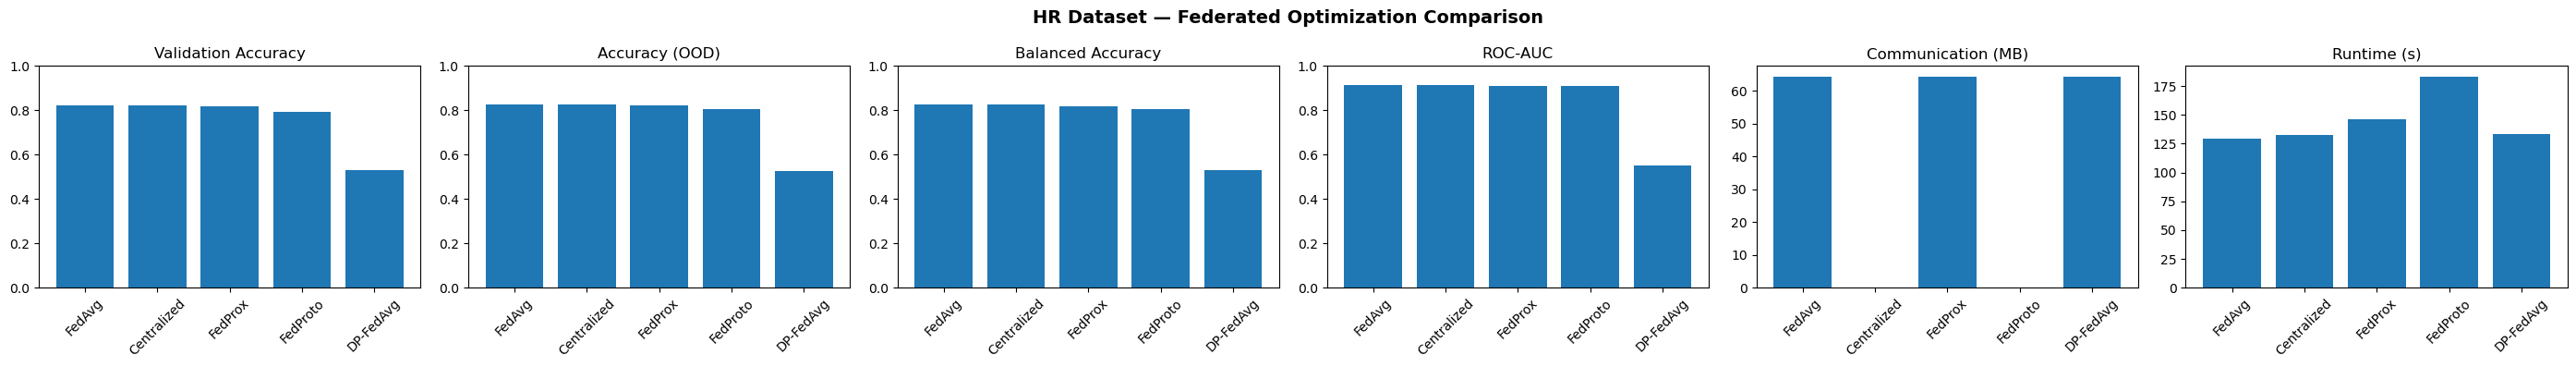

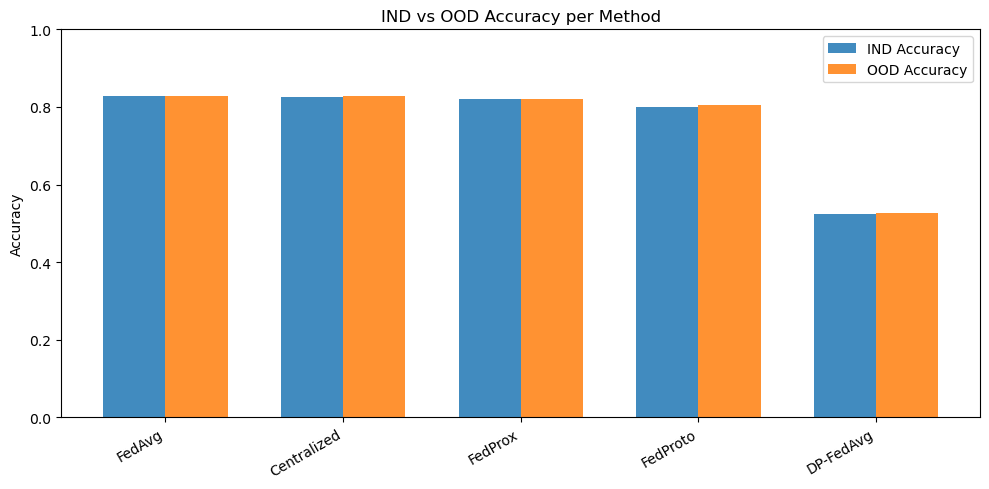

,val_acc,ood_acc,ind_acc,balanced_accuracy,roc_auc,f1_macro,train_ood_gap,communication_mb,runtime_s,rounds
method,,,,,,,,,,
Centralized,0.8239,0.8276,0.8262,0.8279,0.9134,0.8276,0.0130,0.0000,132.7458,0.0000
FedAvg,0.8240,0.8280,0.8279,0.8279,0.9137,0.8278,0.0075,64.3570,129.2243,20.0000
FedProx,0.8170,0.8215,0.8203,0.8200,0.9101,0.8206,0.0038,64.3570,146.0157,20.0000
FedProto,0.7935,0.8063,0.7992,0.8065,0.9097,0.8040,-0.0029,0.1953,183.2355,20.0000
DP-FedAvg,0.5297,0.5269,0.5234,0.5323,0.5531,0.5175,-0.0083,64.3570,133.2437,20.0000


In [25]:
# ============================================
# INSTALLING AND IMPORTING REQUIREMENTS
# ============================================
import copy
import time
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

# ============================================
# FIX RANDOMNESS
# ============================================
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# ============================================
# DATASET PATH
# ============================================
HR_DATA_PATH = Path("stackoverflow_full.csv")

# ============================================
# EXPERIMENT SETTINGS
# ============================================
CONFIG = {
    "rounds":               20,
    "local_epochs":         2,
    "batch_size":           128,
    "lr_tabular":           7e-3,
    "hidden_dim":           256,
    "num_clients":          5,
    "fedprox_mu":           0.01,
    "fedproto_lambda":      0.1,
    "dp_noise_multiplier":  0.3,
    "dp_clip":              1.0,
    "tabular_client_alpha": 1.0,
}

# ============================================
# LOADING THE HR DATASET
# ============================================
def load_hr_dataset(csv_path: Path):
    if not csv_path.exists():
        alt_path = Path("core") / csv_path
        csv_path = alt_path if alt_path.exists() else csv_path
    if not csv_path.exists():
        raise FileNotFoundError(
            f"HR dataset not found at {csv_path}. Check HR_DATA_PATH."
        )

    df = pd.read_csv(csv_path)
    df.columns = [str(c).strip() for c in df.columns]

    if "Unnamed: 0" in df.columns:
        df = df.drop(columns=["Unnamed: 0"])

    target_col = "Employed"

    df = df.dropna(axis=0, how="all").dropna(axis=1, how="all")

    for col in df.select_dtypes(include="object").columns:
        df[col] = df[col].astype(str).str.strip()

    X = df.drop(columns=[target_col]).copy()
    y = df[target_col].copy()

    class_counts = y.value_counts().to_dict()

    return X, y, {
        "target_column": target_col,
        "rows": len(df),
        "columns": list(df.columns),
        "class_counts": class_counts,
        "class_balance": {k: round(v / len(y), 4) for k, v in class_counts.items()},
        "notes": "Dropped Unnamed: 0 and used Employed as binary target. All strings stripped.",
    }

# ============================================
# FEATURE ENGINEERING
# ============================================
def engineer_hr_features(X: pd.DataFrame) -> pd.DataFrame:
    X = X.copy()

    for col in X.select_dtypes(include="object").columns:
        X[col] = X[col].astype(str).str.strip()

    if "HaveWorkedWith" in X.columns:
        hww = X["HaveWorkedWith"].fillna("")
        X["TechStackCount"] = hww.apply(lambda s: len([t for t in s.split(";") if t.strip()]))
        X["HasPython"]      = hww.str.contains("Python", regex=False).astype(int)
        X["HasSQL"]         = hww.str.contains("SQL", regex=False).astype(int)
        X["HasDocker"]      = hww.str.contains("Docker", regex=False).astype(int)
        X["HasAWS"]         = hww.str.contains("AWS", regex=False).astype(int)
        X["HasCloud"]       = hww.str.contains("AWS|Azure|Google Cloud", regex=True).astype(int)
        X["HasJS"]          = hww.str.contains("JavaScript", regex=False).astype(int)
        X["HasTypeScript"]  = hww.str.contains("TypeScript", regex=False).astype(int)
        X = X.drop(columns=["HaveWorkedWith"])

    if {"YearsCode", "YearsCodePro"}.issubset(X.columns):
        X["YearsCode"]    = pd.to_numeric(X["YearsCode"], errors="coerce")
        X["YearsCodePro"] = pd.to_numeric(X["YearsCodePro"], errors="coerce")
        X["YearsCodeGap"] = (X["YearsCode"] - X["YearsCodePro"]).clip(lower=0)

    if "MainBranch" in X.columns:
        X["IsDeveloper"] = (X["MainBranch"].str.strip() == "Dev").astype(int)

    return X

# ============================================
# PREPROCESSOR
# ============================================
def build_preprocessor(X_train: pd.DataFrame):
    numeric_cols = X_train.select_dtypes(include=[np.number, "bool"]).columns.tolist()
    categorical_cols = [c for c in X_train.columns if c not in numeric_cols]

    numeric_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    preprocessor = ColumnTransformer([
        ("num", numeric_pipe, numeric_cols),
        ("cat", categorical_pipe, categorical_cols),
    ])

    return preprocessor, numeric_cols, categorical_cols

# ============================================
# PREPARE DATASET WITH TRAIN / VAL / IND / OOD
# ============================================
def prepare_hr_dataset_country_shift(
    X: pd.DataFrame, y,
    domain_col="Country",
    num_ood_countries=3,
    min_country_samples=300
):
    df = X.copy()
    y_series = pd.Series(y).copy()
    label_encoder = LabelEncoder()
    df["_target"] = label_encoder.fit_transform(y_series.astype(str))

    country_stats = (
        df.groupby(domain_col)["_target"]
        .agg(n_samples="count", n_classes="nunique")
        .sort_values("n_samples", ascending=False)
    )

    eligible = country_stats[
        (country_stats["n_samples"] >= min_country_samples) &
        (country_stats["n_classes"] >= 2)
    ]

    preferred_drop = "United States of America"
    if preferred_drop in eligible.index and len(eligible) > num_ood_countries:
        eligible = eligible.drop(preferred_drop)

    if len(eligible) < num_ood_countries:
        eligible = country_stats[country_stats["n_samples"] >= min_country_samples]
        if preferred_drop in eligible.index and len(eligible) > num_ood_countries:
            eligible = eligible.drop(preferred_drop)

    ood_countries = eligible.index[:num_ood_countries].tolist()
    print(f"OOD countries selected: {ood_countries}")

    seen_df = df[~df[domain_col].isin(ood_countries)].copy()
    ood_df  = df[df[domain_col].isin(ood_countries)].copy()

    stratify_seen = seen_df["_target"] if len(np.unique(seen_df["_target"])) > 1 else None

    # 70% train, 30% temp
    train_df, temp_df = train_test_split(
        seen_df,
        test_size=0.30,
        random_state=SEED,
        stratify=stratify_seen
    )

    # 15% val, 15% IND test
    stratify_temp = temp_df["_target"] if len(np.unique(temp_df["_target"])) > 1 else None
    val_df, ind_df = train_test_split(
        temp_df,
        test_size=0.50,
        random_state=SEED,
        stratify=stratify_temp
    )

    X_train_raw = train_df.drop(columns=["_target"])
    X_val_raw   = val_df.drop(columns=["_target"])
    X_ind_raw   = ind_df.drop(columns=["_target"])
    X_ood_raw   = ood_df.drop(columns=["_target"])

    y_train = train_df["_target"].to_numpy(dtype=np.int64)
    y_val   = val_df["_target"].to_numpy(dtype=np.int64)
    y_ind   = ind_df["_target"].to_numpy(dtype=np.int64)
    y_ood   = ood_df["_target"].to_numpy(dtype=np.int64)

    preprocessor, numeric_cols, categorical_cols = build_preprocessor(X_train_raw)

    X_train_proc = preprocessor.fit_transform(X_train_raw)
    X_val_proc   = preprocessor.transform(X_val_raw)
    X_ind_proc   = preprocessor.transform(X_ind_raw)
    X_ood_proc   = preprocessor.transform(X_ood_raw)

    if hasattr(X_train_proc, "toarray"):
        X_train_proc = X_train_proc.toarray()
        X_val_proc   = X_val_proc.toarray()
        X_ind_proc   = X_ind_proc.toarray()
        X_ood_proc   = X_ood_proc.toarray()

    X_train_proc = X_train_proc.astype(np.float32)
    X_val_proc   = X_val_proc.astype(np.float32)
    X_ind_proc   = X_ind_proc.astype(np.float32)
    X_ood_proc   = X_ood_proc.astype(np.float32)

    sensitive_cols = [
        c for c in ["Gender", "Age", "MentalHealth", "Accessibility"]
        if c in X_train_raw.columns
    ]

    return {
        "X_train":      X_train_proc,
        "X_val":        X_val_proc,
        "X_test":       X_ind_proc,
        "X_ind_test":   X_ind_proc,
        "X_ood_test":   X_ood_proc,
        "y_train":      y_train,
        "y_val":        y_val,
        "y_test":       y_ind,
        "y_ind_test":   y_ind,
        "y_ood_test":   y_ood,
        "input_dim":    X_train_proc.shape[1],
        "model_type":   "tabular",
        "num_classes":  int(len(np.unique(y_train))),
        "label_encoder": label_encoder,
        "preprocessor": preprocessor,
        "numeric_cols": numeric_cols,
        "categorical_cols": categorical_cols,
        "ood_countries": ood_countries,
        "X_train_raw":  X_train_raw,
        "X_val_raw":    X_val_raw,
        "X_ind_raw":    X_ind_raw,
        "X_ood_raw":    X_ood_raw,
        "sensitive_cols": sensitive_cols,
    }

# ============================================
# FL UTILITIES
# ============================================
def dirichlet_client_split(y, num_clients=5, alpha=0.6, min_size=32):
    y = np.asarray(y)
    classes = np.unique(y)

    while True:
        client_indices = [[] for _ in range(num_clients)]
        for cls in classes:
            cls_idx = np.where(y == cls)[0]
            np.random.shuffle(cls_idx)
            proportions = np.random.dirichlet(alpha=np.repeat(alpha, num_clients))
            cut_points = (np.cumsum(proportions)[:-1] * len(cls_idx)).astype(int)
            splits = np.split(cls_idx, cut_points)
            for client_id, split in enumerate(splits):
                client_indices[client_id].extend(split.tolist())

        sizes = [len(idx) for idx in client_indices]
        if min(sizes) >= min_size:
            return [np.array(sorted(idx)) for idx in client_indices]


def make_loader(X, y, batch_size=256, shuffle=True):
    ds = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.long)
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


def build_client_loaders(prepared, num_clients=5, batch_size=256, cfg=None):
    alpha = (cfg or {}).get("tabular_client_alpha", 0.6)
    client_indices = dirichlet_client_split(
        prepared["y_train"], num_clients=num_clients, alpha=alpha, min_size=32
    )

    client_loaders = []
    client_sizes = []

    for idx in client_indices:
        loader = make_loader(
            prepared["X_train"][idx],
            prepared["y_train"][idx],
            batch_size=batch_size,
            shuffle=True
        )
        client_loaders.append(loader)
        client_sizes.append(len(idx))

    return client_loaders, client_sizes

# ============================================
# TABULARNET MODEL
# ============================================
class TabularNet(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes, dropout=0.3):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.classifier = nn.Linear(hidden_dim // 2, num_classes)

    def forward_features(self, x):
        return self.encoder(x)

    def forward(self, x):
        features = self.forward_features(x)
        logits = self.classifier(features)
        return logits, features


def build_model(prepared, cfg):
    return TabularNet(
        prepared["input_dim"],
        cfg["hidden_dim"],
        prepared["num_classes"]
    )

# ============================================
# MODEL STATE UTILITIES
# ============================================
def model_num_bytes(model: nn.Module) -> int:
    return sum(p.numel() * p.element_size() for p in model.parameters())


def get_state(model):
    return {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}


def load_state(model, state):
    model.load_state_dict(state)


def weighted_average_states(states, weights):
    out = copy.deepcopy(states[0])
    for key in out:
        out[key] = sum(w * states[i][key] for i, w in enumerate(weights))
    return out


def state_to_vector(state):
    return torch.cat([v.reshape(-1).float() for v in state.values()])


def client_weights_from_sizes(sizes):
    total = sum(sizes)
    return [s / total for s in sizes]

# ============================================
# EVALUATION FUNCTIONS
# ============================================
def evaluate_model(model, loader):
    model.eval()
    preds, labels, probs_list = [], [], []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            logits, _ = model(xb)
            prob = torch.softmax(logits, dim=1).cpu().numpy()
            pred = logits.argmax(dim=1).cpu().numpy()
            preds.extend(pred.tolist())
            labels.extend(yb.numpy().tolist())
            probs_list.append(prob)

    probs_arr = np.concatenate(probs_list, axis=0)
    num_classes = probs_arr.shape[1]
    unique_labels = np.unique(labels)

    if len(unique_labels) > 1:
        roc = roc_auc_score(
            labels,
            probs_arr if num_classes > 2 else probs_arr[:, 1],
            multi_class="ovr",
            average="macro"
        )
    else:
        roc = float("nan")

    return {
        "accuracy": accuracy_score(labels, preds),
        "balanced_accuracy": balanced_accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
        "precision_macro": precision_score(labels, preds, average="macro", zero_division=0),
        "recall_macro": recall_score(labels, preds, average="macro", zero_division=0),
        "roc_auc": float(roc),
    }


def evaluate_personalized_clients(models, loader):
    rows = [evaluate_model(model, loader) for model in models]
    return {
        "accuracy": float(np.mean([r["accuracy"] for r in rows])),
        "accuracy_std": float(np.std([r["accuracy"] for r in rows])),
        "balanced_accuracy": float(np.mean([r["balanced_accuracy"] for r in rows])),
        "f1_macro": float(np.mean([r["f1_macro"] for r in rows])),
        "precision_macro": float(np.mean([r["precision_macro"] for r in rows])),
        "recall_macro": float(np.mean([r["recall_macro"] for r in rows])),
        "roc_auc": float(np.nanmean([r["roc_auc"] for r in rows])),
    }


def get_train_loader(prepared, cfg, shuffle=True):
    return make_loader(
        prepared["X_train"],
        prepared["y_train"],
        batch_size=cfg["batch_size"],
        shuffle=shuffle
    )


def get_val_loader(prepared, cfg):
    return make_loader(
        prepared["X_val"],
        prepared["y_val"],
        batch_size=cfg["batch_size"],
        shuffle=False
    )


def get_ind_loader(prepared, cfg):
    return make_loader(
        prepared["X_ind_test"],
        prepared["y_ind_test"],
        batch_size=cfg["batch_size"],
        shuffle=False
    )


def get_ood_loader(prepared, cfg):
    return make_loader(
        prepared["X_ood_test"],
        prepared["y_ood_test"],
        batch_size=cfg["batch_size"],
        shuffle=False
    )

# ============================================
# PROTOTYPE UTILITIES (FEDPROTO)
# ============================================
def compute_class_prototypes(model, loader, num_classes):
    model.eval()
    proto_sum = defaultdict(list)

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            _, feats = model(xb)

            for cls in range(num_classes):
                mask = (yb == cls)
                if mask.any():
                    proto_sum[int(cls)].append(feats[mask].mean(dim=0).detach().cpu())

    protos = {}
    for cls, items in proto_sum.items():
        protos[cls] = torch.stack(items).mean(dim=0)

    return protos


def aggregate_prototypes(proto_dicts):
    merged = defaultdict(list)

    for proto_dict in proto_dicts:
        for cls, proto in proto_dict.items():
            merged[int(cls)].append(proto)

    global_protos = {}
    for cls, items in merged.items():
        global_protos[int(cls)] = torch.stack(items).mean(dim=0)

    return global_protos


def prototype_num_bytes(protos):
    return sum(p.numel() * p.element_size() for p in protos.values())

# ============================================
# LOCAL TRAINING
# ============================================
def local_train_epoch(
    model,
    loader,
    optimizer,
    criterion,
    global_state=None,
    prox_mu=0.0,
    global_protos=None,
    proto_lambda=0.0
):
    model.train()

    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()

        logits, feats = model(xb)
        loss = criterion(logits, yb)

        if global_state is not None and prox_mu > 0:
            prox_term = 0.0
            for name, param in model.state_dict().items():
                prox_term += torch.sum((param - global_state[name].to(param.device)) ** 2)
            loss = loss + 0.5 * prox_mu * prox_term

        if global_protos is not None and proto_lambda > 0:
            proto_loss = 0.0
            count = 0

            for cls in torch.unique(yb):
                cls_int = int(cls.item())
                if cls_int in global_protos:
                    cls_mask = (yb == cls)
                    cls_feat = feats[cls_mask].mean(dim=0)
                    proto_loss += F.mse_loss(cls_feat, global_protos[cls_int].to(DEVICE))
                    count += 1

            if count > 0:
                loss = loss + proto_lambda * (proto_loss / count)

        loss.backward()
        optimizer.step()


def _make_optimizer(model, cfg):
    return torch.optim.Adam(model.parameters(), lr=cfg.get("lr_tabular", 1e-3))

# ============================================
# TRAINING METHODS
# ============================================
def centralized_train(prepared, cfg):
    model = build_model(prepared, cfg).to(DEVICE)
    optimizer = _make_optimizer(model, cfg)
    criterion = nn.CrossEntropyLoss()

    train_loader = get_train_loader(prepared, cfg, shuffle=True)
    val_loader   = get_val_loader(prepared, cfg)
    ind_loader   = get_ind_loader(prepared, cfg)
    ood_loader   = get_ood_loader(prepared, cfg)

    total_epochs = cfg["rounds"] * cfg["local_epochs"]
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_epochs)

    best_val_acc = -1.0
    best_state = None

    start = time.time()
    for _ in range(total_epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits, _ = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

        scheduler.step()

        val_metrics = evaluate_model(model, val_loader)
        if val_metrics["accuracy"] > best_val_acc:
            best_val_acc = val_metrics["accuracy"]
            best_state = get_state(model)

    runtime = time.time() - start

    if best_state is not None:
        load_state(model, best_state)

    val_metrics   = evaluate_model(model, val_loader)
    ind_metrics   = evaluate_model(model, ind_loader)
    ood_metrics   = evaluate_model(model, ood_loader)
    train_metrics = evaluate_model(model, get_train_loader(prepared, cfg, shuffle=False))
    train_ood_gap = train_metrics["accuracy"] - ood_metrics["accuracy"]

    return {
        "method": "Centralized",
        "model": model,
        "val_metrics": val_metrics,
        "metrics": ood_metrics,
        "ind_metrics": ind_metrics,
        "ood_metrics": ood_metrics,
        "runtime_s": runtime,
        "communication_mb": 0.0,
        "rounds": 0,
        "train_ood_gap": train_ood_gap,
    }


def run_fedavg(prepared, cfg, dp_noise_multiplier=0.0, dp_clip=None, record_history=False):
    client_loaders, client_sizes = build_client_loaders(
        prepared, num_clients=cfg["num_clients"], batch_size=cfg["batch_size"], cfg=cfg
    )

    global_model = build_model(prepared, cfg).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    history = []
    communication_bytes = 0

    val_loader = get_val_loader(prepared, cfg)
    best_val_acc = -1.0
    best_state = None

    start = time.time()

    for rnd in range(cfg["rounds"]):
        base_state = get_state(global_model)
        client_states = []

        for loader in client_loaders:
            local_model = build_model(prepared, cfg).to(DEVICE)
            load_state(local_model, base_state)
            optimizer = _make_optimizer(local_model, cfg)
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=cfg["local_epochs"]
            )

            for _ in range(cfg["local_epochs"]):
                local_train_epoch(local_model, loader, optimizer, criterion)
                scheduler.step()

            client_states.append(get_state(local_model))

        weights = client_weights_from_sizes(client_sizes)

        if dp_noise_multiplier > 0:
            deltas = []
            for state in client_states:
                delta = {k: state[k] - base_state[k] for k in state}
                vec = state_to_vector(delta)
                norm = torch.linalg.vector_norm(vec).item()

                scale = 1.0
                if dp_clip is not None and norm > dp_clip:
                    scale = dp_clip / (norm + 1e-12)

                clipped = {k: v * scale for k, v in delta.items()}
                deltas.append(clipped)

            agg_delta = weighted_average_states(deltas, weights)

            for key in agg_delta:
                noise = torch.randn_like(agg_delta[key]) * (dp_noise_multiplier * (dp_clip or 1.0))
                agg_delta[key] = agg_delta[key] + noise / len(client_states)

            next_state = {k: base_state[k] + agg_delta[k] for k in base_state}
        else:
            next_state = weighted_average_states(client_states, weights)

        load_state(global_model, next_state)
        communication_bytes += model_num_bytes(global_model) * len(client_loaders) * 2

        val_metrics = evaluate_model(global_model, val_loader)
        if val_metrics["accuracy"] > best_val_acc:
            best_val_acc = val_metrics["accuracy"]
            best_state = get_state(global_model)

        if record_history:
            history.append({
                "round": rnd + 1,
                "base_state": copy.deepcopy(base_state),
                "client_states": copy.deepcopy(client_states),
                "weights": list(weights),
                "val_accuracy": val_metrics["accuracy"],
            })

    runtime = time.time() - start

    if best_state is not None:
        load_state(global_model, best_state)

    val_metrics   = evaluate_model(global_model, val_loader)
    ind_metrics   = evaluate_model(global_model, get_ind_loader(prepared, cfg))
    ood_metrics   = evaluate_model(global_model, get_ood_loader(prepared, cfg))
    train_metrics = evaluate_model(global_model, get_train_loader(prepared, cfg, shuffle=False))
    train_ood_gap = train_metrics["accuracy"] - ood_metrics["accuracy"]

    return {
        "method": "DP-FedAvg" if dp_noise_multiplier > 0 else "FedAvg",
        "model": global_model,
        "val_metrics": val_metrics,
        "metrics": ood_metrics,
        "ind_metrics": ind_metrics,
        "ood_metrics": ood_metrics,
        "runtime_s": runtime,
        "communication_mb": communication_bytes / (1024 ** 2),
        "rounds": cfg["rounds"],
        "train_ood_gap": train_ood_gap,
        "history": history,
    }


def run_fedprox(prepared, cfg):
    client_loaders, client_sizes = build_client_loaders(
        prepared, num_clients=cfg["num_clients"], batch_size=cfg["batch_size"], cfg=cfg
    )

    global_model = build_model(prepared, cfg).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    communication_bytes = 0

    val_loader = get_val_loader(prepared, cfg)
    best_val_acc = -1.0
    best_state = None

    start = time.time()

    for rnd in range(cfg["rounds"]):
        base_state = get_state(global_model)
        client_states = []

        for loader in client_loaders:
            local_model = build_model(prepared, cfg).to(DEVICE)
            load_state(local_model, base_state)
            optimizer = _make_optimizer(local_model, cfg)
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=cfg["local_epochs"]
            )

            for _ in range(cfg["local_epochs"]):
                local_train_epoch(
                    local_model,
                    loader,
                    optimizer,
                    criterion,
                    global_state=base_state,
                    prox_mu=cfg["fedprox_mu"]
                )
                scheduler.step()

            client_states.append(get_state(local_model))

        load_state(
            global_model,
            weighted_average_states(client_states, client_weights_from_sizes(client_sizes))
        )
        communication_bytes += model_num_bytes(global_model) * len(client_loaders) * 2

        val_metrics = evaluate_model(global_model, val_loader)
        if val_metrics["accuracy"] > best_val_acc:
            best_val_acc = val_metrics["accuracy"]
            best_state = get_state(global_model)

    runtime = time.time() - start

    if best_state is not None:
        load_state(global_model, best_state)

    val_metrics   = evaluate_model(global_model, val_loader)
    ind_metrics   = evaluate_model(global_model, get_ind_loader(prepared, cfg))
    ood_metrics   = evaluate_model(global_model, get_ood_loader(prepared, cfg))
    train_metrics = evaluate_model(global_model, get_train_loader(prepared, cfg, shuffle=False))
    train_ood_gap = train_metrics["accuracy"] - ood_metrics["accuracy"]

    return {
        "method": "FedProx",
        "model": global_model,
        "val_metrics": val_metrics,
        "metrics": ood_metrics,
        "ind_metrics": ind_metrics,
        "ood_metrics": ood_metrics,
        "runtime_s": runtime,
        "communication_mb": communication_bytes / (1024 ** 2),
        "rounds": cfg["rounds"],
        "train_ood_gap": train_ood_gap,
    }


def run_fedproto(prepared, cfg):
    client_loaders, _ = build_client_loaders(
        prepared, num_clients=cfg["num_clients"], batch_size=cfg["batch_size"], cfg=cfg
    )

    client_models = [build_model(prepared, cfg).to(DEVICE) for _ in range(cfg["num_clients"])]
    criterion = nn.CrossEntropyLoss()
    global_protos = {}
    communication_bytes = 0

    val_loader = get_val_loader(prepared, cfg)
    best_val_acc = -1.0
    best_models = None
    best_protos = None

    start = time.time()

    for rnd in range(cfg["rounds"]):
        round_protos = []
        round_proto_bytes = 0

        for model, loader in zip(client_models, client_loaders):
            optimizer = _make_optimizer(model, cfg)
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=cfg["local_epochs"]
            )

            for _ in range(cfg["local_epochs"]):
                local_train_epoch(
                    model,
                    loader,
                    optimizer,
                    criterion,
                    global_protos=global_protos,
                    proto_lambda=cfg["fedproto_lambda"]
                )
                scheduler.step()

            local_protos = compute_class_prototypes(model, loader, prepared["num_classes"])
            round_protos.append(local_protos)
            round_proto_bytes += prototype_num_bytes(local_protos)

        global_protos = aggregate_prototypes(round_protos)
        communication_bytes += round_proto_bytes + prototype_num_bytes(global_protos) * len(client_models)

        val_metrics = evaluate_personalized_clients(client_models, val_loader)
        if val_metrics["accuracy"] > best_val_acc:
            best_val_acc = val_metrics["accuracy"]
            best_models = [copy.deepcopy(m).to(DEVICE) for m in client_models]
            best_protos = copy.deepcopy(global_protos)

    runtime = time.time() - start

    if best_models is not None:
        client_models = best_models
        global_protos = best_protos

    val_metrics   = evaluate_personalized_clients(client_models, val_loader)
    ind_metrics   = evaluate_personalized_clients(client_models, get_ind_loader(prepared, cfg))
    ood_metrics   = evaluate_personalized_clients(client_models, get_ood_loader(prepared, cfg))
    train_metrics = evaluate_personalized_clients(client_models, get_train_loader(prepared, cfg, shuffle=False))
    train_ood_gap = train_metrics["accuracy"] - ood_metrics["accuracy"]

    return {
        "method": "FedProto",
        "model": client_models,
        "val_metrics": val_metrics,
        "metrics": ood_metrics,
        "ind_metrics": ind_metrics,
        "ood_metrics": ood_metrics,
        "runtime_s": runtime,
        "communication_mb": communication_bytes / (1024 ** 2),
        "rounds": cfg["rounds"],
        "train_ood_gap": train_ood_gap,
        "global_protos": global_protos,
    }

# ============================================
# FAIRNESS SUBGROUP ANALYSIS
# ============================================
def fairness_subgroup_analysis(model, prepared, cfg, split="ind"):
    sensitive_cols = prepared.get("sensitive_cols", [])
    if not sensitive_cols:
        print("No sensitive columns found in prepared dataset.")
        return pd.DataFrame()

    raw_key = "X_ind_raw" if split == "ind" else "X_ood_raw"
    y_key   = "y_ind_test" if split == "ind" else "y_ood_test"

    X_raw = prepared.get(raw_key)
    y_true = prepared.get(y_key)

    if X_raw is None or y_true is None:
        print(f"Raw split {split} not available.")
        return pd.DataFrame()

    X_raw = X_raw.reset_index(drop=True)
    rows = []

    for col in sensitive_cols:
        if col not in X_raw.columns:
            continue

        for group_val, sub_df in X_raw.groupby(col):
            idx = sub_df.index.tolist()
            y_sub = y_true[idx]

            if len(y_sub) < 10:
                continue

            X_proc = prepared["preprocessor"].transform(sub_df)
            if hasattr(X_proc, "toarray"):
                X_proc = X_proc.toarray()
            X_proc = X_proc.astype(np.float32)

            loader = make_loader(X_proc, y_sub, batch_size=256, shuffle=False)

            if isinstance(model, list):
                metrics = evaluate_personalized_clients(model, loader)
            else:
                metrics = evaluate_model(model, loader)

            rows.append({
                "split": split,
                "sensitive_col": col,
                "group": str(group_val),
                "n": int(len(y_sub)),
                "accuracy": round(metrics["accuracy"], 4),
                "balanced_accuracy": round(metrics.get("balanced_accuracy", float("nan")), 4),
                "f1_macro": round(metrics["f1_macro"], 4),
            })

    return pd.DataFrame(rows)

# ============================================
# MAIN EXPERIMENT
# ============================================
print("Loading HR dataset...")
X, y, hr_info = load_hr_dataset(HR_DATA_PATH)
print(f"Dataset info: {hr_info['rows']} rows | Target: {hr_info['target_column']}")
print(f"Class balance: {hr_info['class_balance']}")

X = engineer_hr_features(X)
prepared = prepare_hr_dataset_country_shift(X, y)

print(f"\nInput dim: {prepared['input_dim']} | Classes: {prepared['num_classes']}")
print(f"Train size: {len(prepared['X_train'])}")
print(f"Val size: {len(prepared['X_val'])}")
print(f"IND test size: {len(prepared['X_ind_test'])}")
print(f"OOD test size: {len(prepared['X_ood_test'])}")
print(f"Sensitive columns: {prepared['sensitive_cols']}")

experiment_store = {}
all_results = []

print("\n--- Centralized Training ---")
centralized = centralized_train(prepared, CONFIG)
experiment_store["Centralized"] = centralized

print("\n--- FedAvg ---")
fedavg = run_fedavg(prepared, CONFIG, record_history=True)
experiment_store["FedAvg"] = fedavg

print("\n--- FedProx ---")
fedprox = run_fedprox(prepared, CONFIG)
experiment_store["FedProx"] = fedprox

print("\n--- FedProto ---")
fedproto = run_fedproto(prepared, CONFIG)
experiment_store["FedProto"] = fedproto

print("\n--- DP-FedAvg ---")
dpfedavg = run_fedavg(
    prepared,
    CONFIG,
    dp_noise_multiplier=CONFIG["dp_noise_multiplier"],
    dp_clip=CONFIG["dp_clip"],
)
experiment_store["DP-FedAvg"] = dpfedavg

for result in [centralized, fedavg, fedprox, fedproto, dpfedavg]:
    all_results.append({
        "method":            result["method"],
        "val_acc":           result["val_metrics"]["accuracy"],
        "accuracy":          result["metrics"]["accuracy"],
        "ood_acc":           result["ood_metrics"]["accuracy"],
        "ind_acc":           result["ind_metrics"]["accuracy"],
        "balanced_accuracy": result["metrics"].get("balanced_accuracy", float("nan")),
        "roc_auc":           result["metrics"].get("roc_auc", float("nan")),
        "f1_macro":          result["metrics"]["f1_macro"],
        "precision_macro":   result["metrics"]["precision_macro"],
        "recall_macro":      result["metrics"]["recall_macro"],
        "runtime_s":         result["runtime_s"],
        "communication_mb":  result["communication_mb"],
        "rounds":            result["rounds"],
        "train_ood_gap":     result["train_ood_gap"],
    })

results_df = pd.DataFrame(all_results).sort_values("accuracy", ascending=False)

display(results_df.style.format({
    "val_acc": "{:.4f}",
    "accuracy": "{:.4f}",
    "balanced_accuracy": "{:.4f}",
    "roc_auc": "{:.4f}",
    "f1_macro": "{:.4f}",
    "precision_macro": "{:.4f}",
    "recall_macro": "{:.4f}",
    "ood_acc": "{:.4f}",
    "ind_acc": "{:.4f}",
    "runtime_s": "{:.2f}",
    "communication_mb": "{:.4f}",
    "train_ood_gap": "{:.4f}",
}))

# ============================================
# VISUALISATION
# ============================================
fig, axes = plt.subplots(1, 6, figsize=(28, 4))
fig.suptitle("HR Dataset — Federated Optimization Comparison", fontsize=14, fontweight="bold")

axes[0].bar(results_df["method"], results_df["val_acc"])
axes[0].set_title("Validation Accuracy")
axes[0].tick_params(axis="x", rotation=45)
axes[0].set_ylim(0, 1)

axes[1].bar(results_df["method"], results_df["accuracy"])
axes[1].set_title("Accuracy (OOD)")
axes[1].tick_params(axis="x", rotation=45)
axes[1].set_ylim(0, 1)

axes[2].bar(results_df["method"], results_df["balanced_accuracy"])
axes[2].set_title("Balanced Accuracy")
axes[2].tick_params(axis="x", rotation=45)
axes[2].set_ylim(0, 1)

axes[3].bar(results_df["method"], results_df["roc_auc"])
axes[3].set_title("ROC-AUC")
axes[3].tick_params(axis="x", rotation=45)
axes[3].set_ylim(0, 1)

axes[4].bar(results_df["method"], results_df["communication_mb"])
axes[4].set_title("Communication (MB)")
axes[4].tick_params(axis="x", rotation=45)

axes[5].bar(results_df["method"], results_df["runtime_s"])
axes[5].set_title("Runtime (s)")
axes[5].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# IND vs OOD
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(results_df))
width = 0.35
ax.bar(x - width/2, results_df["ind_acc"], width, label="IND Accuracy", alpha=0.85)
ax.bar(x + width/2, results_df["ood_acc"], width, label="OOD Accuracy", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(results_df["method"], rotation=30, ha="right")
ax.set_ylim(0, 1)
ax.set_title("IND vs OOD Accuracy per Method")
ax.set_ylabel("Accuracy")
ax.legend()
plt.tight_layout()
plt.show()

# ============================================
# PAPER-STYLE SUMMARY
# ============================================
method_order = ["Centralized", "FedAvg", "FedProx", "FedProto", "DP-FedAvg"]
summary = results_df.set_index("method").reindex(method_order)[
    ["val_acc", "ood_acc", "ind_acc", "balanced_accuracy", "roc_auc", "f1_macro",
     "train_ood_gap", "communication_mb", "runtime_s", "rounds"]
]

def highlight_best(col):
    valid = col.dropna()
    if valid.empty:
        return ["" for _ in col]
    best = valid.min() if col.name in ["train_ood_gap", "communication_mb", "runtime_s", "rounds"] else valid.max()
    return ["font-weight: bold; background-color: #d4edda" if pd.notna(v) and v == best else "" for v in col]

display(summary.style.format("{:.4f}").apply(highlight_best, axis=0))

Using device: cpu
Loading HR dataset...
Dataset info: 73462 rows | Target: Employed
Class balance: {1: 0.5362, 0: 0.4638}
OOD countries selected: ['Germany', 'India', 'United Kingdom of Great Britain and Northern Ireland']

Input dim: 196 | Classes: 2
Train size: 40613
Val size: 8703
IND test size: 8703
OOD test size: 15443
Sensitive columns: ['Gender', 'Age', 'MentalHealth', 'Accessibility']

--- Centralized Training ---

--- FedAvg ---

--- FedProx ---

--- FedProto ---

--- DP-FedAvg ---


,method,val_acc,accuracy,ood_acc,ind_acc,balanced_accuracy,roc_auc,f1_macro,precision_macro,recall_macro,runtime_s,communication_mb,rounds,train_ood_gap
1,FedAvg,0.8253,0.8283,0.8283,0.8249,0.8280,0.9132,0.8281,0.8281,0.8280,389.10,172.9271,30,0.0070
0,Centralized,0.8260,0.8282,0.8282,0.8241,0.8280,0.9134,0.8280,0.8280,0.8280,393.29,0.0000,0,0.0140
2,FedProx,0.8247,0.8272,0.8272,0.8264,0.8280,0.9133,0.8272,0.8278,0.8280,449.82,172.9271,30,0.0070
3,FedProto,0.7985,0.8115,0.8115,0.8007,0.8105,0.9071,0.8093,0.8203,0.8105,521.52,0.4395,30,-0.0033
4,DP-FedAvg,0.6535,0.6637,0.6637,0.6493,0.6686,0.7547,0.6586,0.6824,0.6686,386.11,172.9271,30,-0.0160


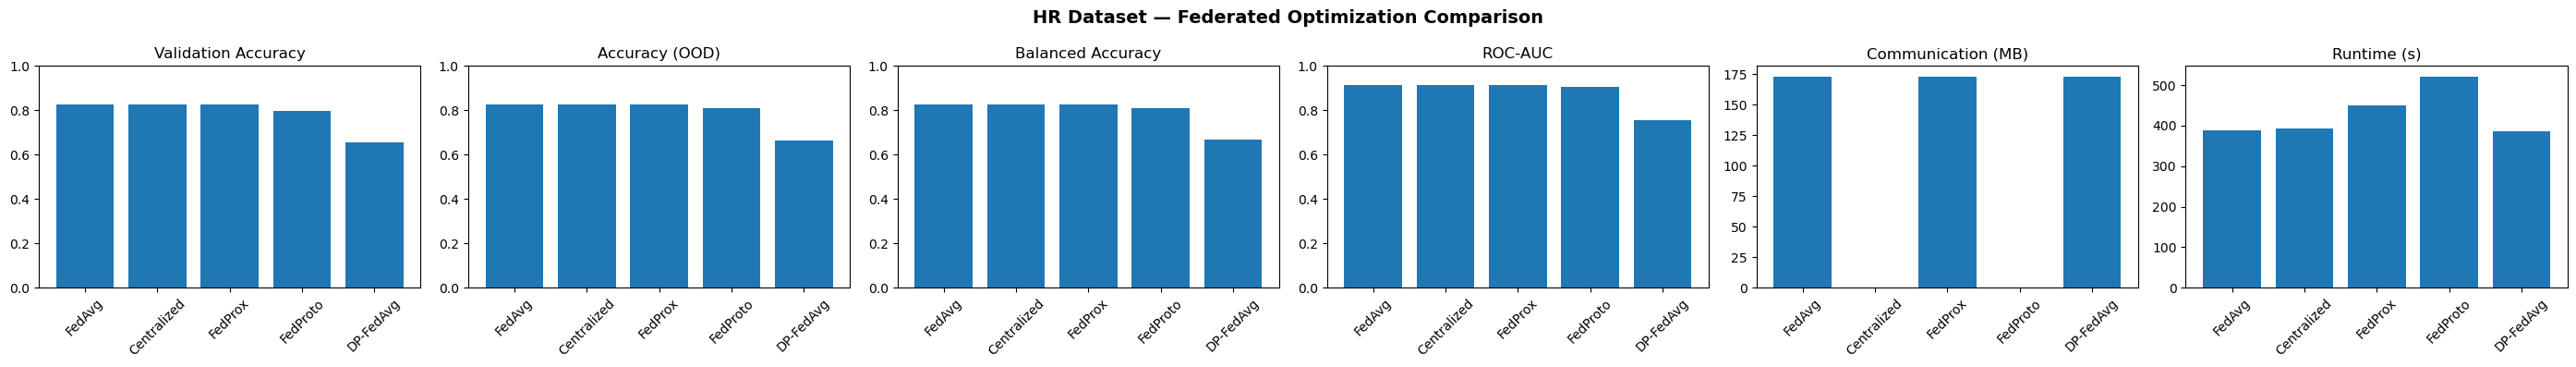

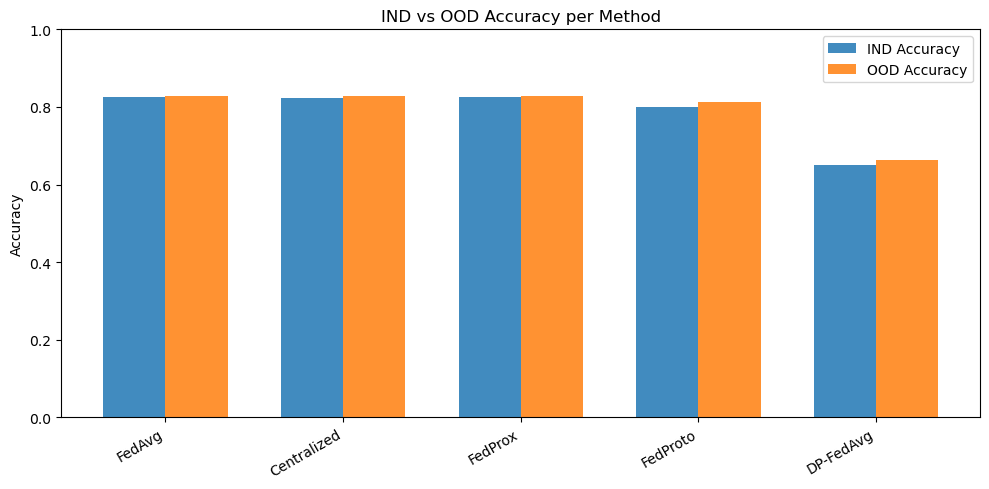

,val_acc,ood_acc,ind_acc,balanced_accuracy,roc_auc,f1_macro,train_ood_gap,communication_mb,runtime_s,rounds
method,,,,,,,,,,
Centralized,0.8260,0.8282,0.8241,0.8280,0.9134,0.8280,0.0140,0.0000,393.2883,0.0000
FedAvg,0.8253,0.8283,0.8249,0.8280,0.9132,0.8281,0.0070,172.9271,389.1014,30.0000
FedProx,0.8247,0.8272,0.8264,0.8280,0.9133,0.8272,0.0070,172.9271,449.8171,30.0000
FedProto,0.7985,0.8115,0.8007,0.8105,0.9071,0.8093,-0.0033,0.4395,521.5206,30.0000
DP-FedAvg,0.6535,0.6637,0.6493,0.6686,0.7547,0.6586,-0.0160,172.9271,386.1071,30.0000


In [26]:
# ============================================
# INSTALLING AND IMPORTING REQUIREMENTS
# ============================================
import copy
import time
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

# ============================================
# FIX RANDOMNESS
# ============================================
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# ============================================
# DATASET PATH
# ============================================
HR_DATA_PATH = Path("stackoverflow_full.csv")

# ============================================
# EXPERIMENT SETTINGS
# ============================================
CONFIG = {
    "rounds":               30,
    "local_epochs":         2,
    "batch_size":           64,
    "lr_tabular":           5e-3,
    "hidden_dim":           384,
    "num_clients":          5,
    "fedprox_mu":           0.001,
    "fedproto_lambda":      0.001,
    "dp_noise_multiplier":  0.15,
    "dp_clip":              1.5,
    "tabular_client_alpha": 2.0,
}

# ============================================
# LOADING THE HR DATASET
# ============================================
def load_hr_dataset(csv_path: Path):
    if not csv_path.exists():
        alt_path = Path("core") / csv_path
        csv_path = alt_path if alt_path.exists() else csv_path
    if not csv_path.exists():
        raise FileNotFoundError(
            f"HR dataset not found at {csv_path}. Check HR_DATA_PATH."
        )

    df = pd.read_csv(csv_path)
    df.columns = [str(c).strip() for c in df.columns]

    if "Unnamed: 0" in df.columns:
        df = df.drop(columns=["Unnamed: 0"])

    target_col = "Employed"

    df = df.dropna(axis=0, how="all").dropna(axis=1, how="all")

    for col in df.select_dtypes(include="object").columns:
        df[col] = df[col].astype(str).str.strip()

    X = df.drop(columns=[target_col]).copy()
    y = df[target_col].copy()

    class_counts = y.value_counts().to_dict()

    return X, y, {
        "target_column": target_col,
        "rows": len(df),
        "columns": list(df.columns),
        "class_counts": class_counts,
        "class_balance": {k: round(v / len(y), 4) for k, v in class_counts.items()},
        "notes": "Dropped Unnamed: 0 and used Employed as binary target. All strings stripped.",
    }

# ============================================
# FEATURE ENGINEERING
# ============================================
def engineer_hr_features(X: pd.DataFrame) -> pd.DataFrame:
    X = X.copy()

    for col in X.select_dtypes(include="object").columns:
        X[col] = X[col].astype(str).str.strip()

    if "HaveWorkedWith" in X.columns:
        hww = X["HaveWorkedWith"].fillna("")
        X["TechStackCount"] = hww.apply(lambda s: len([t for t in s.split(";") if t.strip()]))
        X["HasPython"]      = hww.str.contains("Python", regex=False).astype(int)
        X["HasSQL"]         = hww.str.contains("SQL", regex=False).astype(int)
        X["HasDocker"]      = hww.str.contains("Docker", regex=False).astype(int)
        X["HasAWS"]         = hww.str.contains("AWS", regex=False).astype(int)
        X["HasCloud"]       = hww.str.contains("AWS|Azure|Google Cloud", regex=True).astype(int)
        X["HasJS"]          = hww.str.contains("JavaScript", regex=False).astype(int)
        X["HasTypeScript"]  = hww.str.contains("TypeScript", regex=False).astype(int)
        X = X.drop(columns=["HaveWorkedWith"])

    if {"YearsCode", "YearsCodePro"}.issubset(X.columns):
        X["YearsCode"]    = pd.to_numeric(X["YearsCode"], errors="coerce")
        X["YearsCodePro"] = pd.to_numeric(X["YearsCodePro"], errors="coerce")
        X["YearsCodeGap"] = (X["YearsCode"] - X["YearsCodePro"]).clip(lower=0)

    if "MainBranch" in X.columns:
        X["IsDeveloper"] = (X["MainBranch"].str.strip() == "Dev").astype(int)

    return X

# ============================================
# PREPROCESSOR
# ============================================
def build_preprocessor(X_train: pd.DataFrame):
    numeric_cols = X_train.select_dtypes(include=[np.number, "bool"]).columns.tolist()
    categorical_cols = [c for c in X_train.columns if c not in numeric_cols]

    numeric_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    preprocessor = ColumnTransformer([
        ("num", numeric_pipe, numeric_cols),
        ("cat", categorical_pipe, categorical_cols),
    ])

    return preprocessor, numeric_cols, categorical_cols

# ============================================
# PREPARE DATASET WITH TRAIN / VAL / IND / OOD
# ============================================
def prepare_hr_dataset_country_shift(
    X: pd.DataFrame, y,
    domain_col="Country",
    num_ood_countries=3,
    min_country_samples=300
):
    df = X.copy()
    y_series = pd.Series(y).copy()
    label_encoder = LabelEncoder()
    df["_target"] = label_encoder.fit_transform(y_series.astype(str))

    country_stats = (
        df.groupby(domain_col)["_target"]
        .agg(n_samples="count", n_classes="nunique")
        .sort_values("n_samples", ascending=False)
    )

    eligible = country_stats[
        (country_stats["n_samples"] >= min_country_samples) &
        (country_stats["n_classes"] >= 2)
    ]

    preferred_drop = "United States of America"
    if preferred_drop in eligible.index and len(eligible) > num_ood_countries:
        eligible = eligible.drop(preferred_drop)

    if len(eligible) < num_ood_countries:
        eligible = country_stats[country_stats["n_samples"] >= min_country_samples]
        if preferred_drop in eligible.index and len(eligible) > num_ood_countries:
            eligible = eligible.drop(preferred_drop)

    ood_countries = eligible.index[:num_ood_countries].tolist()
    print(f"OOD countries selected: {ood_countries}")

    seen_df = df[~df[domain_col].isin(ood_countries)].copy()
    ood_df  = df[df[domain_col].isin(ood_countries)].copy()

    stratify_seen = seen_df["_target"] if len(np.unique(seen_df["_target"])) > 1 else None

    # 70% train, 30% temp
    train_df, temp_df = train_test_split(
        seen_df,
        test_size=0.30,
        random_state=SEED,
        stratify=stratify_seen
    )

    # 15% val, 15% IND test
    stratify_temp = temp_df["_target"] if len(np.unique(temp_df["_target"])) > 1 else None
    val_df, ind_df = train_test_split(
        temp_df,
        test_size=0.50,
        random_state=SEED,
        stratify=stratify_temp
    )

    X_train_raw = train_df.drop(columns=["_target"])
    X_val_raw   = val_df.drop(columns=["_target"])
    X_ind_raw   = ind_df.drop(columns=["_target"])
    X_ood_raw   = ood_df.drop(columns=["_target"])

    y_train = train_df["_target"].to_numpy(dtype=np.int64)
    y_val   = val_df["_target"].to_numpy(dtype=np.int64)
    y_ind   = ind_df["_target"].to_numpy(dtype=np.int64)
    y_ood   = ood_df["_target"].to_numpy(dtype=np.int64)

    preprocessor, numeric_cols, categorical_cols = build_preprocessor(X_train_raw)

    X_train_proc = preprocessor.fit_transform(X_train_raw)
    X_val_proc   = preprocessor.transform(X_val_raw)
    X_ind_proc   = preprocessor.transform(X_ind_raw)
    X_ood_proc   = preprocessor.transform(X_ood_raw)

    if hasattr(X_train_proc, "toarray"):
        X_train_proc = X_train_proc.toarray()
        X_val_proc   = X_val_proc.toarray()
        X_ind_proc   = X_ind_proc.toarray()
        X_ood_proc   = X_ood_proc.toarray()

    X_train_proc = X_train_proc.astype(np.float32)
    X_val_proc   = X_val_proc.astype(np.float32)
    X_ind_proc   = X_ind_proc.astype(np.float32)
    X_ood_proc   = X_ood_proc.astype(np.float32)

    sensitive_cols = [
        c for c in ["Gender", "Age", "MentalHealth", "Accessibility"]
        if c in X_train_raw.columns
    ]

    return {
        "X_train":      X_train_proc,
        "X_val":        X_val_proc,
        "X_test":       X_ind_proc,
        "X_ind_test":   X_ind_proc,
        "X_ood_test":   X_ood_proc,
        "y_train":      y_train,
        "y_val":        y_val,
        "y_test":       y_ind,
        "y_ind_test":   y_ind,
        "y_ood_test":   y_ood,
        "input_dim":    X_train_proc.shape[1],
        "model_type":   "tabular",
        "num_classes":  int(len(np.unique(y_train))),
        "label_encoder": label_encoder,
        "preprocessor": preprocessor,
        "numeric_cols": numeric_cols,
        "categorical_cols": categorical_cols,
        "ood_countries": ood_countries,
        "X_train_raw":  X_train_raw,
        "X_val_raw":    X_val_raw,
        "X_ind_raw":    X_ind_raw,
        "X_ood_raw":    X_ood_raw,
        "sensitive_cols": sensitive_cols,
    }

# ============================================
# FL UTILITIES
# ============================================
def dirichlet_client_split(y, num_clients=5, alpha=0.6, min_size=32):
    y = np.asarray(y)
    classes = np.unique(y)

    while True:
        client_indices = [[] for _ in range(num_clients)]
        for cls in classes:
            cls_idx = np.where(y == cls)[0]
            np.random.shuffle(cls_idx)
            proportions = np.random.dirichlet(alpha=np.repeat(alpha, num_clients))
            cut_points = (np.cumsum(proportions)[:-1] * len(cls_idx)).astype(int)
            splits = np.split(cls_idx, cut_points)
            for client_id, split in enumerate(splits):
                client_indices[client_id].extend(split.tolist())

        sizes = [len(idx) for idx in client_indices]
        if min(sizes) >= min_size:
            return [np.array(sorted(idx)) for idx in client_indices]


def make_loader(X, y, batch_size=256, shuffle=True):
    ds = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.long)
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


def build_client_loaders(prepared, num_clients=5, batch_size=256, cfg=None):
    alpha = (cfg or {}).get("tabular_client_alpha", 0.6)
    client_indices = dirichlet_client_split(
        prepared["y_train"], num_clients=num_clients, alpha=alpha, min_size=32
    )

    client_loaders = []
    client_sizes = []

    for idx in client_indices:
        loader = make_loader(
            prepared["X_train"][idx],
            prepared["y_train"][idx],
            batch_size=batch_size,
            shuffle=True
        )
        client_loaders.append(loader)
        client_sizes.append(len(idx))

    return client_loaders, client_sizes

# ============================================
# TABULARNET MODEL
# ============================================
class TabularNet(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes, dropout=0.3):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.classifier = nn.Linear(hidden_dim // 2, num_classes)

    def forward_features(self, x):
        return self.encoder(x)

    def forward(self, x):
        features = self.forward_features(x)
        logits = self.classifier(features)
        return logits, features


def build_model(prepared, cfg):
    return TabularNet(
        prepared["input_dim"],
        cfg["hidden_dim"],
        prepared["num_classes"]
    )

# ============================================
# MODEL STATE UTILITIES
# ============================================
def model_num_bytes(model: nn.Module) -> int:
    return sum(p.numel() * p.element_size() for p in model.parameters())


def get_state(model):
    return {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}


def load_state(model, state):
    model.load_state_dict(state)


def weighted_average_states(states, weights):
    out = copy.deepcopy(states[0])
    for key in out:
        out[key] = sum(w * states[i][key] for i, w in enumerate(weights))
    return out


def state_to_vector(state):
    return torch.cat([v.reshape(-1).float() for v in state.values()])


def client_weights_from_sizes(sizes):
    total = sum(sizes)
    return [s / total for s in sizes]

# ============================================
# EVALUATION FUNCTIONS
# ============================================
def evaluate_model(model, loader):
    model.eval()
    preds, labels, probs_list = [], [], []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            logits, _ = model(xb)
            prob = torch.softmax(logits, dim=1).cpu().numpy()
            pred = logits.argmax(dim=1).cpu().numpy()
            preds.extend(pred.tolist())
            labels.extend(yb.numpy().tolist())
            probs_list.append(prob)

    probs_arr = np.concatenate(probs_list, axis=0)
    num_classes = probs_arr.shape[1]
    unique_labels = np.unique(labels)

    if len(unique_labels) > 1:
        roc = roc_auc_score(
            labels,
            probs_arr if num_classes > 2 else probs_arr[:, 1],
            multi_class="ovr",
            average="macro"
        )
    else:
        roc = float("nan")

    return {
        "accuracy": accuracy_score(labels, preds),
        "balanced_accuracy": balanced_accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
        "precision_macro": precision_score(labels, preds, average="macro", zero_division=0),
        "recall_macro": recall_score(labels, preds, average="macro", zero_division=0),
        "roc_auc": float(roc),
    }


def evaluate_personalized_clients(models, loader):
    rows = [evaluate_model(model, loader) for model in models]
    return {
        "accuracy": float(np.mean([r["accuracy"] for r in rows])),
        "accuracy_std": float(np.std([r["accuracy"] for r in rows])),
        "balanced_accuracy": float(np.mean([r["balanced_accuracy"] for r in rows])),
        "f1_macro": float(np.mean([r["f1_macro"] for r in rows])),
        "precision_macro": float(np.mean([r["precision_macro"] for r in rows])),
        "recall_macro": float(np.mean([r["recall_macro"] for r in rows])),
        "roc_auc": float(np.nanmean([r["roc_auc"] for r in rows])),
    }


def get_train_loader(prepared, cfg, shuffle=True):
    return make_loader(
        prepared["X_train"],
        prepared["y_train"],
        batch_size=cfg["batch_size"],
        shuffle=shuffle
    )


def get_val_loader(prepared, cfg):
    return make_loader(
        prepared["X_val"],
        prepared["y_val"],
        batch_size=cfg["batch_size"],
        shuffle=False
    )


def get_ind_loader(prepared, cfg):
    return make_loader(
        prepared["X_ind_test"],
        prepared["y_ind_test"],
        batch_size=cfg["batch_size"],
        shuffle=False
    )


def get_ood_loader(prepared, cfg):
    return make_loader(
        prepared["X_ood_test"],
        prepared["y_ood_test"],
        batch_size=cfg["batch_size"],
        shuffle=False
    )

# ============================================
# PROTOTYPE UTILITIES (FEDPROTO)
# ============================================
def compute_class_prototypes(model, loader, num_classes):
    model.eval()
    proto_sum = defaultdict(list)

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            _, feats = model(xb)

            for cls in range(num_classes):
                mask = (yb == cls)
                if mask.any():
                    proto_sum[int(cls)].append(feats[mask].mean(dim=0).detach().cpu())

    protos = {}
    for cls, items in proto_sum.items():
        protos[cls] = torch.stack(items).mean(dim=0)

    return protos


def aggregate_prototypes(proto_dicts):
    merged = defaultdict(list)

    for proto_dict in proto_dicts:
        for cls, proto in proto_dict.items():
            merged[int(cls)].append(proto)

    global_protos = {}
    for cls, items in merged.items():
        global_protos[int(cls)] = torch.stack(items).mean(dim=0)

    return global_protos


def prototype_num_bytes(protos):
    return sum(p.numel() * p.element_size() for p in protos.values())

# ============================================
# LOCAL TRAINING
# ============================================
def local_train_epoch(
    model,
    loader,
    optimizer,
    criterion,
    global_state=None,
    prox_mu=0.0,
    global_protos=None,
    proto_lambda=0.0
):
    model.train()

    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()

        logits, feats = model(xb)
        loss = criterion(logits, yb)

        if global_state is not None and prox_mu > 0:
            prox_term = 0.0
            for name, param in model.state_dict().items():
                prox_term += torch.sum((param - global_state[name].to(param.device)) ** 2)
            loss = loss + 0.5 * prox_mu * prox_term

        if global_protos is not None and proto_lambda > 0:
            proto_loss = 0.0
            count = 0

            for cls in torch.unique(yb):
                cls_int = int(cls.item())
                if cls_int in global_protos:
                    cls_mask = (yb == cls)
                    cls_feat = feats[cls_mask].mean(dim=0)
                    proto_loss += F.mse_loss(cls_feat, global_protos[cls_int].to(DEVICE))
                    count += 1

            if count > 0:
                loss = loss + proto_lambda * (proto_loss / count)

        loss.backward()
        optimizer.step()


def _make_optimizer(model, cfg):
    return torch.optim.Adam(model.parameters(), lr=cfg.get("lr_tabular", 1e-3))

# ============================================
# TRAINING METHODS
# ============================================
def centralized_train(prepared, cfg):
    model = build_model(prepared, cfg).to(DEVICE)
    optimizer = _make_optimizer(model, cfg)
    criterion = nn.CrossEntropyLoss()

    train_loader = get_train_loader(prepared, cfg, shuffle=True)
    val_loader   = get_val_loader(prepared, cfg)
    ind_loader   = get_ind_loader(prepared, cfg)
    ood_loader   = get_ood_loader(prepared, cfg)

    total_epochs = cfg["rounds"] * cfg["local_epochs"]
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_epochs)

    best_val_acc = -1.0
    best_state = None

    start = time.time()
    for _ in range(total_epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits, _ = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

        scheduler.step()

        val_metrics = evaluate_model(model, val_loader)
        if val_metrics["accuracy"] > best_val_acc:
            best_val_acc = val_metrics["accuracy"]
            best_state = get_state(model)

    runtime = time.time() - start

    if best_state is not None:
        load_state(model, best_state)

    val_metrics   = evaluate_model(model, val_loader)
    ind_metrics   = evaluate_model(model, ind_loader)
    ood_metrics   = evaluate_model(model, ood_loader)
    train_metrics = evaluate_model(model, get_train_loader(prepared, cfg, shuffle=False))
    train_ood_gap = train_metrics["accuracy"] - ood_metrics["accuracy"]

    return {
        "method": "Centralized",
        "model": model,
        "val_metrics": val_metrics,
        "metrics": ood_metrics,
        "ind_metrics": ind_metrics,
        "ood_metrics": ood_metrics,
        "runtime_s": runtime,
        "communication_mb": 0.0,
        "rounds": 0,
        "train_ood_gap": train_ood_gap,
    }


def run_fedavg(prepared, cfg, dp_noise_multiplier=0.0, dp_clip=None, record_history=False):
    client_loaders, client_sizes = build_client_loaders(
        prepared, num_clients=cfg["num_clients"], batch_size=cfg["batch_size"], cfg=cfg
    )

    global_model = build_model(prepared, cfg).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    history = []
    communication_bytes = 0

    val_loader = get_val_loader(prepared, cfg)
    best_val_acc = -1.0
    best_state = None

    start = time.time()

    for rnd in range(cfg["rounds"]):
        base_state = get_state(global_model)
        client_states = []

        for loader in client_loaders:
            local_model = build_model(prepared, cfg).to(DEVICE)
            load_state(local_model, base_state)
            optimizer = _make_optimizer(local_model, cfg)
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=cfg["local_epochs"]
            )

            for _ in range(cfg["local_epochs"]):
                local_train_epoch(local_model, loader, optimizer, criterion)
                scheduler.step()

            client_states.append(get_state(local_model))

        weights = client_weights_from_sizes(client_sizes)

        if dp_noise_multiplier > 0:
            deltas = []
            for state in client_states:
                delta = {k: state[k] - base_state[k] for k in state}
                vec = state_to_vector(delta)
                norm = torch.linalg.vector_norm(vec).item()

                scale = 1.0
                if dp_clip is not None and norm > dp_clip:
                    scale = dp_clip / (norm + 1e-12)

                clipped = {k: v * scale for k, v in delta.items()}
                deltas.append(clipped)

            agg_delta = weighted_average_states(deltas, weights)

            for key in agg_delta:
                noise = torch.randn_like(agg_delta[key]) * (dp_noise_multiplier * (dp_clip or 1.0))
                agg_delta[key] = agg_delta[key] + noise / len(client_states)

            next_state = {k: base_state[k] + agg_delta[k] for k in base_state}
        else:
            next_state = weighted_average_states(client_states, weights)

        load_state(global_model, next_state)
        communication_bytes += model_num_bytes(global_model) * len(client_loaders) * 2

        val_metrics = evaluate_model(global_model, val_loader)
        if val_metrics["accuracy"] > best_val_acc:
            best_val_acc = val_metrics["accuracy"]
            best_state = get_state(global_model)

        if record_history:
            history.append({
                "round": rnd + 1,
                "base_state": copy.deepcopy(base_state),
                "client_states": copy.deepcopy(client_states),
                "weights": list(weights),
                "val_accuracy": val_metrics["accuracy"],
            })

    runtime = time.time() - start

    if best_state is not None:
        load_state(global_model, best_state)

    val_metrics   = evaluate_model(global_model, val_loader)
    ind_metrics   = evaluate_model(global_model, get_ind_loader(prepared, cfg))
    ood_metrics   = evaluate_model(global_model, get_ood_loader(prepared, cfg))
    train_metrics = evaluate_model(global_model, get_train_loader(prepared, cfg, shuffle=False))
    train_ood_gap = train_metrics["accuracy"] - ood_metrics["accuracy"]

    return {
        "method": "DP-FedAvg" if dp_noise_multiplier > 0 else "FedAvg",
        "model": global_model,
        "val_metrics": val_metrics,
        "metrics": ood_metrics,
        "ind_metrics": ind_metrics,
        "ood_metrics": ood_metrics,
        "runtime_s": runtime,
        "communication_mb": communication_bytes / (1024 ** 2),
        "rounds": cfg["rounds"],
        "train_ood_gap": train_ood_gap,
        "history": history,
    }


def run_fedprox(prepared, cfg):
    client_loaders, client_sizes = build_client_loaders(
        prepared, num_clients=cfg["num_clients"], batch_size=cfg["batch_size"], cfg=cfg
    )

    global_model = build_model(prepared, cfg).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    communication_bytes = 0

    val_loader = get_val_loader(prepared, cfg)
    best_val_acc = -1.0
    best_state = None

    start = time.time()

    for rnd in range(cfg["rounds"]):
        base_state = get_state(global_model)
        client_states = []

        for loader in client_loaders:
            local_model = build_model(prepared, cfg).to(DEVICE)
            load_state(local_model, base_state)
            optimizer = _make_optimizer(local_model, cfg)
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=cfg["local_epochs"]
            )

            for _ in range(cfg["local_epochs"]):
                local_train_epoch(
                    local_model,
                    loader,
                    optimizer,
                    criterion,
                    global_state=base_state,
                    prox_mu=cfg["fedprox_mu"]
                )
                scheduler.step()

            client_states.append(get_state(local_model))

        load_state(
            global_model,
            weighted_average_states(client_states, client_weights_from_sizes(client_sizes))
        )
        communication_bytes += model_num_bytes(global_model) * len(client_loaders) * 2

        val_metrics = evaluate_model(global_model, val_loader)
        if val_metrics["accuracy"] > best_val_acc:
            best_val_acc = val_metrics["accuracy"]
            best_state = get_state(global_model)

    runtime = time.time() - start

    if best_state is not None:
        load_state(global_model, best_state)

    val_metrics   = evaluate_model(global_model, val_loader)
    ind_metrics   = evaluate_model(global_model, get_ind_loader(prepared, cfg))
    ood_metrics   = evaluate_model(global_model, get_ood_loader(prepared, cfg))
    train_metrics = evaluate_model(global_model, get_train_loader(prepared, cfg, shuffle=False))
    train_ood_gap = train_metrics["accuracy"] - ood_metrics["accuracy"]

    return {
        "method": "FedProx",
        "model": global_model,
        "val_metrics": val_metrics,
        "metrics": ood_metrics,
        "ind_metrics": ind_metrics,
        "ood_metrics": ood_metrics,
        "runtime_s": runtime,
        "communication_mb": communication_bytes / (1024 ** 2),
        "rounds": cfg["rounds"],
        "train_ood_gap": train_ood_gap,
    }


def run_fedproto(prepared, cfg):
    client_loaders, _ = build_client_loaders(
        prepared, num_clients=cfg["num_clients"], batch_size=cfg["batch_size"], cfg=cfg
    )

    client_models = [build_model(prepared, cfg).to(DEVICE) for _ in range(cfg["num_clients"])]
    criterion = nn.CrossEntropyLoss()
    global_protos = {}
    communication_bytes = 0

    val_loader = get_val_loader(prepared, cfg)
    best_val_acc = -1.0
    best_models = None
    best_protos = None

    start = time.time()

    for rnd in range(cfg["rounds"]):
        round_protos = []
        round_proto_bytes = 0

        for model, loader in zip(client_models, client_loaders):
            optimizer = _make_optimizer(model, cfg)
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=cfg["local_epochs"]
            )

            for _ in range(cfg["local_epochs"]):
                local_train_epoch(
                    model,
                    loader,
                    optimizer,
                    criterion,
                    global_protos=global_protos,
                    proto_lambda=cfg["fedproto_lambda"]
                )
                scheduler.step()

            local_protos = compute_class_prototypes(model, loader, prepared["num_classes"])
            round_protos.append(local_protos)
            round_proto_bytes += prototype_num_bytes(local_protos)

        global_protos = aggregate_prototypes(round_protos)
        communication_bytes += round_proto_bytes + prototype_num_bytes(global_protos) * len(client_models)

        val_metrics = evaluate_personalized_clients(client_models, val_loader)
        if val_metrics["accuracy"] > best_val_acc:
            best_val_acc = val_metrics["accuracy"]
            best_models = [copy.deepcopy(m).to(DEVICE) for m in client_models]
            best_protos = copy.deepcopy(global_protos)

    runtime = time.time() - start

    if best_models is not None:
        client_models = best_models
        global_protos = best_protos

    val_metrics   = evaluate_personalized_clients(client_models, val_loader)
    ind_metrics   = evaluate_personalized_clients(client_models, get_ind_loader(prepared, cfg))
    ood_metrics   = evaluate_personalized_clients(client_models, get_ood_loader(prepared, cfg))
    train_metrics = evaluate_personalized_clients(client_models, get_train_loader(prepared, cfg, shuffle=False))
    train_ood_gap = train_metrics["accuracy"] - ood_metrics["accuracy"]

    return {
        "method": "FedProto",
        "model": client_models,
        "val_metrics": val_metrics,
        "metrics": ood_metrics,
        "ind_metrics": ind_metrics,
        "ood_metrics": ood_metrics,
        "runtime_s": runtime,
        "communication_mb": communication_bytes / (1024 ** 2),
        "rounds": cfg["rounds"],
        "train_ood_gap": train_ood_gap,
        "global_protos": global_protos,
    }

# ============================================
# FAIRNESS SUBGROUP ANALYSIS
# ============================================
def fairness_subgroup_analysis(model, prepared, cfg, split="ind"):
    sensitive_cols = prepared.get("sensitive_cols", [])
    if not sensitive_cols:
        print("No sensitive columns found in prepared dataset.")
        return pd.DataFrame()

    raw_key = "X_ind_raw" if split == "ind" else "X_ood_raw"
    y_key   = "y_ind_test" if split == "ind" else "y_ood_test"

    X_raw = prepared.get(raw_key)
    y_true = prepared.get(y_key)

    if X_raw is None or y_true is None:
        print(f"Raw split {split} not available.")
        return pd.DataFrame()

    X_raw = X_raw.reset_index(drop=True)
    rows = []

    for col in sensitive_cols:
        if col not in X_raw.columns:
            continue

        for group_val, sub_df in X_raw.groupby(col):
            idx = sub_df.index.tolist()
            y_sub = y_true[idx]

            if len(y_sub) < 10:
                continue

            X_proc = prepared["preprocessor"].transform(sub_df)
            if hasattr(X_proc, "toarray"):
                X_proc = X_proc.toarray()
            X_proc = X_proc.astype(np.float32)

            loader = make_loader(X_proc, y_sub, batch_size=256, shuffle=False)

            if isinstance(model, list):
                metrics = evaluate_personalized_clients(model, loader)
            else:
                metrics = evaluate_model(model, loader)

            rows.append({
                "split": split,
                "sensitive_col": col,
                "group": str(group_val),
                "n": int(len(y_sub)),
                "accuracy": round(metrics["accuracy"], 4),
                "balanced_accuracy": round(metrics.get("balanced_accuracy", float("nan")), 4),
                "f1_macro": round(metrics["f1_macro"], 4),
            })

    return pd.DataFrame(rows)

# ============================================
# MAIN EXPERIMENT
# ============================================
print("Loading HR dataset...")
X, y, hr_info = load_hr_dataset(HR_DATA_PATH)
print(f"Dataset info: {hr_info['rows']} rows | Target: {hr_info['target_column']}")
print(f"Class balance: {hr_info['class_balance']}")

X = engineer_hr_features(X)
prepared = prepare_hr_dataset_country_shift(X, y)

print(f"\nInput dim: {prepared['input_dim']} | Classes: {prepared['num_classes']}")
print(f"Train size: {len(prepared['X_train'])}")
print(f"Val size: {len(prepared['X_val'])}")
print(f"IND test size: {len(prepared['X_ind_test'])}")
print(f"OOD test size: {len(prepared['X_ood_test'])}")
print(f"Sensitive columns: {prepared['sensitive_cols']}")

experiment_store = {}
all_results = []

print("\n--- Centralized Training ---")
centralized = centralized_train(prepared, CONFIG)
experiment_store["Centralized"] = centralized

print("\n--- FedAvg ---")
fedavg = run_fedavg(prepared, CONFIG, record_history=True)
experiment_store["FedAvg"] = fedavg

print("\n--- FedProx ---")
fedprox = run_fedprox(prepared, CONFIG)
experiment_store["FedProx"] = fedprox

print("\n--- FedProto ---")
fedproto = run_fedproto(prepared, CONFIG)
experiment_store["FedProto"] = fedproto

print("\n--- DP-FedAvg ---")
dpfedavg = run_fedavg(
    prepared,
    CONFIG,
    dp_noise_multiplier=CONFIG["dp_noise_multiplier"],
    dp_clip=CONFIG["dp_clip"],
)
experiment_store["DP-FedAvg"] = dpfedavg

for result in [centralized, fedavg, fedprox, fedproto, dpfedavg]:
    all_results.append({
        "method":            result["method"],
        "val_acc":           result["val_metrics"]["accuracy"],
        "accuracy":          result["metrics"]["accuracy"],
        "ood_acc":           result["ood_metrics"]["accuracy"],
        "ind_acc":           result["ind_metrics"]["accuracy"],
        "balanced_accuracy": result["metrics"].get("balanced_accuracy", float("nan")),
        "roc_auc":           result["metrics"].get("roc_auc", float("nan")),
        "f1_macro":          result["metrics"]["f1_macro"],
        "precision_macro":   result["metrics"]["precision_macro"],
        "recall_macro":      result["metrics"]["recall_macro"],
        "runtime_s":         result["runtime_s"],
        "communication_mb":  result["communication_mb"],
        "rounds":            result["rounds"],
        "train_ood_gap":     result["train_ood_gap"],
    })

results_df = pd.DataFrame(all_results).sort_values("accuracy", ascending=False)

display(results_df.style.format({
    "val_acc": "{:.4f}",
    "accuracy": "{:.4f}",
    "balanced_accuracy": "{:.4f}",
    "roc_auc": "{:.4f}",
    "f1_macro": "{:.4f}",
    "precision_macro": "{:.4f}",
    "recall_macro": "{:.4f}",
    "ood_acc": "{:.4f}",
    "ind_acc": "{:.4f}",
    "runtime_s": "{:.2f}",
    "communication_mb": "{:.4f}",
    "train_ood_gap": "{:.4f}",
}))

# ============================================
# VISUALISATION
# ============================================
fig, axes = plt.subplots(1, 6, figsize=(28, 4))
fig.suptitle("HR Dataset — Federated Optimization Comparison", fontsize=14, fontweight="bold")

axes[0].bar(results_df["method"], results_df["val_acc"])
axes[0].set_title("Validation Accuracy")
axes[0].tick_params(axis="x", rotation=45)
axes[0].set_ylim(0, 1)

axes[1].bar(results_df["method"], results_df["accuracy"])
axes[1].set_title("Accuracy (OOD)")
axes[1].tick_params(axis="x", rotation=45)
axes[1].set_ylim(0, 1)

axes[2].bar(results_df["method"], results_df["balanced_accuracy"])
axes[2].set_title("Balanced Accuracy")
axes[2].tick_params(axis="x", rotation=45)
axes[2].set_ylim(0, 1)

axes[3].bar(results_df["method"], results_df["roc_auc"])
axes[3].set_title("ROC-AUC")
axes[3].tick_params(axis="x", rotation=45)
axes[3].set_ylim(0, 1)

axes[4].bar(results_df["method"], results_df["communication_mb"])
axes[4].set_title("Communication (MB)")
axes[4].tick_params(axis="x", rotation=45)

axes[5].bar(results_df["method"], results_df["runtime_s"])
axes[5].set_title("Runtime (s)")
axes[5].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# IND vs OOD
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(results_df))
width = 0.35
ax.bar(x - width/2, results_df["ind_acc"], width, label="IND Accuracy", alpha=0.85)
ax.bar(x + width/2, results_df["ood_acc"], width, label="OOD Accuracy", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(results_df["method"], rotation=30, ha="right")
ax.set_ylim(0, 1)
ax.set_title("IND vs OOD Accuracy per Method")
ax.set_ylabel("Accuracy")
ax.legend()
plt.tight_layout()
plt.show()

# ============================================
# PAPER-STYLE SUMMARY
# ============================================
method_order = ["Centralized", "FedAvg", "FedProx", "FedProto", "DP-FedAvg"]
summary = results_df.set_index("method").reindex(method_order)[
    ["val_acc", "ood_acc", "ind_acc", "balanced_accuracy", "roc_auc", "f1_macro",
     "train_ood_gap", "communication_mb", "runtime_s", "rounds"]
]

def highlight_best(col):
    valid = col.dropna()
    if valid.empty:
        return ["" for _ in col]
    best = valid.min() if col.name in ["train_ood_gap", "communication_mb", "runtime_s", "rounds"] else valid.max()
    return ["font-weight: bold; background-color: #d4edda" if pd.notna(v) and v == best else "" for v in col]

display(summary.style.format("{:.4f}").apply(highlight_best, axis=0))